# 03. Feynman integrals at one loop: the lecture note, with feynsage

This notebook goes with the lecture note *Feynman integrals at one loop* of **Prof. B. Ananthanarayan**
(NISER, 2026). It follows the note section by section; every code cell here is one of the "feynsage" boxes
of the note, so the derivations and the pictures are in the note and the calculations are here, ready to
run and to change. The note itself cites V. A. Smirnov, *Feynman Integral Calculus* (Springer, 2006) for most
of the methods.

How to read it: run the cells from the top. A cell may use a name made in an earlier cell of the same
section. If you only know a little Python, `00_start_here.ipynb` is enough to follow everything here.

**Two normalizations are used**, as in the note. The Euclidean integrals of the first sections use the
measure dᴰl/π^{D/2} and propagators l² + m² (the functions `tadpole`, `bubble_...`, `family`, `graph`). The
Minkowski one-loop functions A0, B0, C0, D0 use μ^{2ε}e^{εγ_E}∫dᴰl/(iπ^{D/2}), as Package-X and LoopTools do.
D = 4 − 2ε throughout.

In [1]:
from feynsage import *

## 1. The toolkit, from zero

The Gaussian integral, the Gamma and Beta functions, logarithms of complex numbers and the divergence theorem in D dimensions: the few pieces of mathematics that every loop integral uses.

The Gaussian integral over the real line.

In [2]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
x = var('x')
integral(exp(-x^2), x, -oo, oo)

sqrt(pi)

Its square in polar coordinates.

In [3]:
r, th = var('r th')
integral(integral(r*exp(-r^2), r, 0, oo), th, 0, 2*pi)

pi

Gamma(z) is this integral.

In [4]:
t, z = var('t z')
assume(z > 0)
integral(t^(z - 1)*exp(-t), t, 0, oo)

gamma(z)

Gamma(1), Gamma(5), Gamma(1/2)

In [5]:
gamma(1), gamma(5), gamma(1/2)

(1, 24, sqrt(pi))

Gamma(z + 1) = z Gamma(z)

In [6]:
(gamma(z + 1)/(z*gamma(z))).simplify_full()

1

Residues of Gamma(z) at z = 0, -1, -2.

In [7]:
[gamma(z).residue(z == -k) for k in range(3)]

[1, -1, 1/2]

The Beta function.

In [8]:
u, a, b = var('u a b')
assume(a > 0, b > 0)
integral(u^(a - 1)*(1 - u)^(b - 1), u, 0, 1)

beta(a, b)

Gamma'(1), psi(1) and psi(2)

In [9]:
diff(gamma(z), z).subs(z=1), psi(1), psi(2)

(-euler_gamma, -euler_gamma, -euler_gamma + 1)

The divergence of V^mu = l^mu/(l^2 + m^2)^n at |l| = r, integrated over the D-ball of radius R.

In [10]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
r, R, D, n = var('r R D n'); m2 = var('m2', latex_name='m^2')
assume(R > 0, m2 > 0, D > 0)
Omega = 2*pi^(D/2)/gamma(D/2)
divV = D/(r^2 + m2)^n - 2*n*r^2/(r^2 + m2)^(n + 1)
# r^(D-1) div V is the r-derivative of r^D/(r^2 + m2)^n, so the volume integral is that at R
F = r^D/(r^2 + m2)^n
(diff(F, r) - r^(D - 1)*divV).simplify_full()

0

Volume integral of div V and the surface term Omega_D R^(D-1) V.n.

In [11]:
volume = Omega*F.subs(r=R)
surface = Omega*R^(D - 1)*(R/(R^2 + m2)^n)
volume, (volume - surface).simplify_full()

(2*pi^(1/2*D)*R^D/((R^2 + m2)^n*gamma(1/2*D)), 0)

In D = 4 with Cartesian components.

In [12]:
x1, x2, x3, x4 = var('x1 x2 x3 x4')
xs = [x1, x2, x3, x4]
V4 = [x/(sum(y^2 for y in xs) + m2)^n for x in xs]
sum(diff(V4[i], xs[i]) for i in range(4)).factor()

-2*(n*x1^2 + n*x2^2 + n*x3^2 + n*x4^2 - 2*x1^2 - 2*x2^2 - 2*x3^2 - 2*x4^2 - 2*m2)*(x1^2 + x2^2 + x3^2 + x4^2 + m2)^(-n - 1)

The same as Mathematica's form (m^2 + r^2)^(-n-1) (4 m^2 - 2 (n - 2) r^2), with r^2 = x1^2 + ... + x4^2.

In [13]:
r2 = sum(y^2 for y in xs)
div4_mma = (m2 + r2)^(-n - 1)*(4*m2 - 2*(n - 2)*r2)
(sum(diff(V4[i], xs[i]) for i in range(4)) - div4_mma).simplify_full()

0

## 2. The simplest loop: the tadpole

Where the tadpole comes from, and the Wick rotation from Minkowski to Euclidean space.

The energy integral with the Feynman i eta kept: closing the contour gives 2 pi i times one residue.

In [14]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
l0, e, eta = var('l0 e eta')
assume(e > 0, eta > 0)
root = I*e*sqrt(1 - I*eta/e^2)             # the pole in the upper half plane is at -sqrt(e^2 - i eta) = -root/I ...
(root^2 - (-e^2 + I*eta)).simplify_full()

0

The first two terms in eta of that square root.

In [15]:
root.series(eta, 2).truncate()

I*e + 1/2*eta/e

So the integral pi/sqrt(-e^2 + i eta) tends to.

In [16]:
limit(pi/root, eta=0)

-I*pi/e

Exact check with a = 1 - i/10: integral of 1/((l0 - a)(l0 + a)) and -i pi/a.

In [17]:
a = 1 - I/10
(2*pi*I*(1/(2*(-a)))).simplify(), (-I*pi/a).simplify()

(-(100/101*I - 10/101)*pi, -(100/101*I - 10/101)*pi)

After the Wick rotation l0 = i l4.

In [18]:
l4 = var('l4')
I*integral(1/(-(l4^2 + e^2)), l4, -oo, oo)

-I*pi/e

Minkowski over Euclidean tadpole: i (-1)^n.

In [19]:
n, D, m2 = var('n D m2')
IM = I*(-1)^n*pi^(D/2)*gamma(n - D/2)/gamma(n)*m2^(D/2 - n)
IE = pi^(D/2)*gamma(n - D/2)/gamma(n)*m2^(D/2 - n)
(IM/IE).simplify_full()

I*(-1)^n

## 3. Dimensional regularization

The solid angle in D dimensions, the tadpole for any D and its expansion around D = 4.

The solid angle in D dimensions from the Gaussian trick.

In [20]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
n = var('n')
Omega = lambda D: 2*pi^(D/2)/gamma(D/2)
Omega(2), Omega(3), Omega(4)

(2*pi, 4*pi, 2*pi^2)

The radial Gaussian integral.

In [21]:
x = var('x')
assume(n > 0)
radial = integral(exp(-x^2)*x^(n - 1), x, 0, oo)
radial

1/2*gamma(1/2*n)

Omega_n times the radial integral is pi^(n/2)

In [22]:
(Omega(n)*radial - pi^(n/2)).simplify_full()

0

The radial integral of the Euclidean tadpole (Maxima needs the signs spelled out)

In [23]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
l, m, D, n = var('l m D n')
assume(m > 0, D > 0, n > 0, 2*n - D > 0)
assume(D, 'noninteger'); assume(n, 'noninteger')
radial = integral(l^(D - 1)/(l^2 + m^2)^n, l, 0, oo)
radial

1/2*m^(D - 2*n)*beta(1/2*D, -1/2*D + n)

I_n = Omega_D times the radial integral.

In [24]:
Omega = 2*pi^(D/2)/gamma(D/2)
I_n = (Omega*radial).maxima_methods().makegamma()
I_n

pi^(1/2*D)*m^(D - 2*n)*gamma(-1/2*D + n)/gamma(n)

Feynsage's tadpole is the same, with the measure d^D l/pi^(D/2)

In [25]:
from feynsage.oneloop import tadpole
(I_n - pi^(D/2)*tadpole(n, m^2)).simplify_full()

0

The same with l = m tan(t)

In [26]:
t = var('t')
tan_int = integral(sin(t)^(D - 1)*cos(t)^(2*n - D - 1), t, 0, pi/2)
(Omega*m^(D - 2*n)*tan_int - I_n).simplify_full()

0

## 4. Dots on lines and integration by parts

A dot on a line is one more power of that propagator. Raising powers by differentiating with respect to the mass, the integration-by-parts identity and the difference equation it gives.

Raising the power of a propagator = differentiating in m^2.

In [27]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
from feynsage.oneloop import tadpole, D
m2 = var('m2', latex_name='m^2')
correct = lambda n: (-1)^(n - 1)/factorial(n - 1)*diff(tadpole(1, m2), m2, n - 1)
[(correct(n)/tadpole(n, m2)).simplify_full() for n in [2..5]]

[1, 1, 1, 1]

A tempting but wrong variant.

In [28]:
variant = lambda n: (-1)^n/factorial(n)*diff(tadpole(1, m2), m2, n - 1)
[(variant(n)/tadpole(n, m2)).simplify_full() for n in [2..5]]

[-1/2, -1/3, -1/4, -1/5]

The tadpole family T(n) = Int d^D l/pi^(D/2) 1/(l^2 + m^2)^n; its IBP identity at n = 1 and n = 2.

In [29]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
T = family([("l", "m")], name="T", euclidean=True)
T.ibp_eq(1), T.ibp_eq(2)

([2*m^2*T(2) + (d - 2)*T(1) == 0], [4*m^2*T(3) + (d - 4)*T(2) == 0])

Feynsage reduces T(2) and T(3) to the master T(1)

In [30]:
ibp_reduce(T, ["T(2)", "T(3)"])

T(2) = [(-1/2) * m^-2 * (d - 2)] T(1)
T(3) = [(1/8) * m^-4 * (d - 4) * (d - 2)] T(1)

The same from the closed formula: T(n + 1)/T(n) = (2 - D/n)/(2 m^2)

In [31]:
from feynsage.oneloop import tadpole, D
n = var('n'); m2 = var('m2', latex_name='m^2')
(tadpole(n + 1, m2)/tadpole(n, m2)).simplify_full()

-1/2*(D - 2*n)/(m2*n)

The recurrence -(n - D/2) U(n) + n U(n + 1) = 0, solved.

In [32]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
n, D = var('n D')
U = function('U')
from sympy import rsolve, Function, Symbol
ns, Ds = Symbol('n'), Symbol('D')
Us = Function('U')
SR(rsolve(-(ns - Ds/2)*Us(ns) + ns*Us(ns + 1), Us(ns)))

C0*gamma(-1/2*D + n)/(gamma(-1/2*D + 1)*gamma(n))

The Mellin ansatz U(n) = Int_0^1 t^(n-1) v(t) dt gives a first-order ODE for v.

In [33]:
t = var('t')
v = function('v')(t)
desolve(-t*(t - 1)*diff(v, t) + (D/2 - t)*v == 0, v, ivar=t)

_C*e^(1/2*(D - 2)*log(t - 1) - 1/2*D*log(t))

U(n) from v(t) = v0 t^(-D/2) (1 - t)^(D/2 - 1)

In [34]:
v0 = var('v0')
assume(n > 0, D > 0, 2*n - D > 0)
Un = v0*integral(t^(n - 1 - D/2)*(1 - t)^(D/2 - 1), t, 0, 1)
Un

v0*beta(1/2*D, -1/2*D + n)

V0 from large n: n^(D/2) U(n) -> v0 Gamma(D/2)  (Maxima cannot take this limit, SymPy can)

In [35]:
import sympy                    # Sage passes the limit to SymPy without D > 0, so call SymPy itself
N, Dp = sympy.symbols('n D', positive=True)
v0*gamma(D/2)*SR(sympy.limit(N**(Dp/2)*sympy.gamma(N - Dp/2)/sympy.gamma(N), N, sympy.oo))

v0*gamma(1/2*D)

## 5. The mass correction in λφ⁴

The one-loop tadpole correction to the mass, worked out in Euclidean and in Minkowski space, with the counterterm.

The lambda phi^4 tadpole in D = 2w = 4 - 2 eps dimensions.

In [36]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
lam = var('lam', latex_name=r'\lambda'); mu2 = var('mu2', latex_name=r'\mu^2')
m2 = var('m2', latex_name='m^2'); w = var('w', latex_name=r'\omega')
tad = -lam/2*mu2^(2 - w)*gamma(1 - w)/(4*pi)^w*m2^(w - 1)
expansion = laurent(tad.subs(w=2 - eps), eps, 0)
expansion

-1/32*((euler_gamma - 2*log(2) - log(pi) - 1)*lam*m2 + lam*m2*log(m2) - lam*m2*log(mu2))/pi^2 + 1/32*lam*m2/(pi^2*eps)

Compared with Ramond's form.

In [37]:
assume(m2 > 0, mu2 > 0)
(expansion - lam*m2/(32*pi^2)*(1/eps + psi(2) + log(4*pi*mu2/m2))).canonicalize_radical().expand_log().simplify_full()

0

Psi(2)

In [38]:
psi(2)

-euler_gamma + 1

## 6. The basis of one-loop integrals

Tensor reduction on one example: every one-loop integral is a sum of A0, B0, C0 and D0.

The tensor bubble Int l^mu/([l^2 - m1^2][(l + p)^2 - m2^2]) in Passarino-Veltman functions.

In [39]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
m1, m2 = var('m1 m2')
loop("l^mu", ["l", "m1"], ["l + p", "m2"], kin={"p^2": "s"})

p^mu :  1/2*m1^2*(1/eps + log(mu^2/m1^2) + 1)/s - 1/2*m2^2*(1/eps + log(mu^2/m2^2) + 1)/s + 1/4*(m1^2 - m2^2 + s)*((m1^2 - m2^2 + s)*log(m1^2/m2^2)/s - 2/eps - 2*DiscB(s, m1, m2) - 2*log(mu^2/m2^2) - 4)/s

B1 in terms of A0 and B0.

In [40]:
s, m = var('s m')
PVB(0, 1, s, m1, m2)

1/2*m1^2*(1/eps + log(mu^2/m1^2) + 1)/s - 1/2*m2^2*(1/eps + log(mu^2/m2^2) + 1)/s + 1/4*(m1^2 - m2^2 + s)*((m1^2 - m2^2 + s)*log(m1^2/m2^2)/s - 2/eps - 2*DiscB(s, m1, m2) - 2*log(mu^2/m2^2) - 4)/s

B1 for equal masses.

In [41]:
PVB(0, 1, s, m, m)

-1/2/eps - 1/2*DiscB(s, m, m) - 1/2*log(mu^2/m^2) - 1

The UV poles of A0 and B0 (normalisation of loop(): mu^(2 eps) e^(eps gamma_E) Int d^d l/(i pi^(d/2)))

In [42]:
uv_part(A0(m)), uv_part(B0(s, m, m))

(m^2, 1)

## 7. The bubble: IBP reduction

The bubble family, its two IBP identities, and the reduction of every bubble to two master integrals.

The equal-mass bubble: Euclidean propagators l^2 + m^2 and (l - p)^2 + m^2, p^2 = pp.

In [43]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
J = family([("l", "m"), ("l - p", "m")], kin={"p^2": "pp"}, euclidean=True, name="J")
r = ibp_reduce(J, ["J(2,1)", "J(0,2)"])
[J.integral(*mm) for mm in r.masters]

[J(0, 1), J(1, 1)]

J(2,1) and the dotted tadpole T(2) = J(0,2) in the masters.

In [44]:
r

J(2,1) = [(-1) * (d - 3) * (4*m^2 + pp)^-1] J(1,1) + [(-1/2) * m^-2 * (d - 2) * (4*m^2 + pp)^-1] J(0,1)
J(0,2) = [(-1/2) * m^-2 * (d - 2)] J(0,1)

DJ(1,1)/d(p^2), reduced to the masters.

In [45]:
diff_reduce(J, "J(1,1)", "pp")

-1/2*(4*m^2 - d*pp + 4*pp)*J(1, 1)/((4*m^2 + pp)*pp) - (d - 2)*J(0, 1)/((4*m^2 + pp)*pp)

## 8. The Gauss hypergeometric function

The function ₂F₁ that the massive bubble is made of: series, differential equation, Euler's integral and its expansion in the parameters.

The series of 2F1(a, b; c; z) to z^2.

In [46]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
a, b, c, z = var('a b c z')
hypergeometric([a, b], [c], z).series(z, 3).truncate()

1/2*(a^2*b^2/((c + 1)*c) + a^2*b/((c + 1)*c) + a*b^2/((c + 1)*c) + a*b/((c + 1)*c))*z^2 + a*b*z/c + 1

Special cases: 2F1(1,1;2;z), 2F1(1/2,1/2;3/2;z^2) (for 0 < z < 1), 2F1(a,b;b;z)

In [47]:
assume(z > 0, z < 1)
[hypergeometric([1, 1], [2], z).simplify_hypergeometric(), hypergeometric([1/2, 1/2], [3/2], z^2).simplify_hypergeometric(),
 hypergeometric([a, b], [b], z).simplify_hypergeometric()]

[-log(-z + 1)/z, arcsin(z)/z, 1/((-z + 1)^a)]

The hypergeometric ODE z(1-z)F'' + (c - (a+b+1)z)F' - ab F = 0, checked as a series to z^5.

In [48]:
F = sum(rising_factorial(a, k)*rising_factorial(b, k)/(rising_factorial(c, k)*factorial(k))*z^k for k in range(8))
ode = z*(1 - z)*diff(F, z, 2) + (c - (a + b + 1)*z)*diff(F, z) - a*b*F
[ode.expand().coefficient(z, k).simplify_full() for k in range(6)]

[0, 0, 0, 0, 0, 0]

Euler's integral (1/2) Int_0^1 u^(-1/2)(1 + x u)^(-a) du, term by term, is 2F1(1/2, a; 3/2; -x)

In [49]:
x, u = var('x u')
terms = [rising_factorial(a, k)*(-x)^k/factorial(k)*integral(u^(k - 1/2), u, 0, 1)/2 for k in range(6)]
(sum(terms) - hypergeometric([1/2, a], [3/2], -x).series(x, 6).truncate()).simplify_full()

0

The Euler transformation used for the bubble, as a series to x^5.

In [50]:
dd = var('dd')
e = hypergeometric([(dd - 1)/2, 1/2], [3/2], -x)*(1 + x)^((dd - 3)/2) - hypergeometric([2 - dd/2, 1], [3/2], -x)
[e.series(x, 6).truncate().expand().coefficient(x, k).simplify_full() for k in range(6)]

[0, 0, 0, 0, 0, 0]

2F1(0,1;3/2;z) and the order-eps term of 2F1(eps,1;3/2;z), summed: sum_k (k-1)!/(3/2)_k z^k.

In [51]:
k = var('k')
hypergeometric([0, 1], [3/2], z).simplify_hypergeometric(), sum(factorial(k - 1)/rising_factorial(3/2, k)*z^k, k, 1, oo)

(1,
 2*(z*arcsin(sqrt(z)) + sqrt(z)*sqrt(-z + 1) - arcsin(sqrt(z)))/(sqrt(z)*sqrt(-z + 1)))

## 9. The bubble from a differential equation

Differentiate the bubble with respect to the external momentum, reduce with IBP, and solve the differential equation.

Feynsage derives dJ(1,1)/d(p^2) from IBP (equal masses m = 1, Euclidean, measure d^d l/pi^(d/2))

In [52]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
J = family([("l", 1), ("l - p", 1)], kin={"p^2": "pp"}, euclidean=True, name="J")
dJ = diff_reduce(J, "J(1,1)", "pp")
dJ

1/2*(d*pp - 4*pp - 4)*J(1, 1)/((pp + 4)*pp) - (d - 2)*J(0, 1)/((pp + 4)*pp)

The same equation in x = p^2/(4 m^2), with the tadpole T1 = J(0,1) = Gamma(1 - d/2)

In [53]:
x, d, Jx = var('x d Jx')
T1 = gamma(1 - d/2)
T2 = -(d - 2)/2*T1                                   # the dotted tadpole, from IBP
rhs = (4*dJ).subs(pp=4*x).subs({J.integral(0, 1): T1, J.integral(1, 1): Jx}).simplify_rational()
rhs.coefficient(Jx).factor()*Jx + rhs.subs(Jx=0).factor()

1/2*(d*x - 4*x - 1)*Jx/((x + 1)*x) - 1/4*(d - 2)*gamma(-1/2*d + 1)/((x + 1)*x)

Minus Mathematica's right-hand side, -1/2 (1/x - (d - 3)/(1 + x)) J + T2/(2 x (1 + x))

In [54]:
(rhs - (-(1/x - (d - 3)/(1 + x))*Jx/2 + T2/(2*x*(1 + x)))).simplify_full()

0

The homogeneous solution (solve dJ/dx = c(x) J), divided by Mathematica's (1 + x)^((d - 3)/2)/sqrt(x): a constant.

In [55]:
Jf = function('J')(x)
hom = desolve(diff(Jf, x) == rhs.coefficient(Jx)*Jf, Jf, ivar=x)
assume(x > 0)
(hom/((1 + x)^((d - 3)/2)/sqrt(x))).canonicalize_radical().simplify_full()

_C

The solution regular at x = 0 is T2 2F1(2 - d/2, 1; 3/2; -x): the ODE residual as a series to x^5.

In [56]:
Jreg = T2*hypergeometric([2 - d/2, 1], [3/2], -x)
res = (diff(Jreg, x) - rhs.subs(Jx=Jreg)).series(x, 6).truncate()
[c.simplify_full() for c, k in res.coefficients(x)]

[0, 0, 0, 0, 0, 0]

At x = 0 it is J(1,1) at p = 0, which is Gamma(2 - d/2)

In [57]:
(Jreg.subs(x=0)/gamma(2 - d/2)).simplify_full()

1

The Feynman-parameter form term by term: sum_k (-1)^k (a)_k/k! (4x)^k B(k+1, k+1) and 2F1(1, a; 3/2; -x)

In [58]:
a = var('a')
fp = sum((-1)^k*rising_factorial(a, k)/factorial(k)*(4*x)^k*beta(k + 1, k + 1) for k in range(8))
(fp - hypergeometric([1, a], [3/2], -x).series(x, 8).truncate()).expand()

0

## 10. Feynman parameters and graph polynomials

The general Feynman-parameter formula and the Symanzik polynomials U and F.

The Feynman parameter formula for two denominators with powers a1, a2.

In [59]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
x, A, B = var('x A B')
assume(A > 0, B > 0, B - A > 0)          # Maxima asks which is larger; the answer holds for both
fp = lambda a1, a2: gamma(a1 + a2)/(gamma(a1)*gamma(a2))*integral(x^(a1 - 1)*(1 - x)^(a2 - 1)/(x*A + (1 - x)*B)^(a1 + a2), x, 0, 1)
fp(1, 1).simplify_full()

1/(A*B)

Powers 2 and 3.

In [60]:
(fp(2, 3) - 1/(A^2*B^3)).simplify_full()

0

The bubble: x D1 + (1 - x) D2 and the shift l -> l' + (1 - x) p (scalar products as symbols)

In [61]:
l, p = var('l p'); lp = var('lp', latex_name="l'"); m2 = var('m2', latex_name='m^2')
den = (x*(l^2 + m2) + (1 - x)*((l - p)^2 + m2)).expand()
den, den.subs(l=lp + (1 - x)*p).expand()

(2*l*p*x - p^2*x + l^2 - 2*l*p + p^2 + m2, -p^2*x^2 + p^2*x + lp^2 + m2)

Feynsage gives U and F of the bubble directly.

In [62]:
bub = family([("l", "m"), ("l - p", "m")], kin={"p^2": "p2"}, euclidean=True)
bub.UF()

(x1 + x2, m^2*x1^2 + (2*m^2 + p2)*x1*x2 + m^2*x2^2)

The Feynman parametrisation of the equal-mass bubble (Minkowski, p^2 = s): prefactor, integrand, variables.

In [63]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
bub = family([("l", "m"), ("l - p", "m")], kin={"p^2": "s"})
feynman_parametrize(bub, (1, 1))

(I*gamma(-1/2*D + 2),
 (m^2*x1^2 + m^2*x2^2 + (2*m^2 - s)*x1*x2)^(1/2*D - 2)*(x1 + x2)^(-D + 2),
 [x1, x2])

The tadpole with power 2.

In [64]:
tad = family([("l", "m")])
pref, integrand, xs = feynman_parametrize(tad, (2,))
pref, integrand.subs(x1=1)

(I*gamma(-1/2*D + 2), (m^2)^(1/2*D - 2))

With symbolic powers a1, a2 (the general formula)

In [65]:
feynman_parametrize(bub)

(I*(-1)^(a1 + a2)*gamma(-1/2*D + a1 + a2)/(gamma(a1)*gamma(a2)),
 (m^2*x1^2 + m^2*x2^2 + (2*m^2 - s)*x1*x2)^(1/2*D - a1 - a2)*(x1 + x2)^(-D + a1 + a2)*x1^(a1 - 1)*x2^(a2 - 1),
 [x1, x2])

The triangle with masses: lines l, l - p1, l - p1 - p2 (Euclidean), p1^2 = s1, p2^2 = s2, p1.p2 = s12.

In [66]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
tri = family([("l", "m1"), ("l - p1", "m2"), ("l - p1 - p2", "m3")],
             kin={"p1^2": "s1", "p2^2": "s2", "p1.p2": "s12"}, euclidean=True)
U, F = tri.UF()
U, F

(x1 + x2 + x3,
 m1^2*x1^2 + (m1^2 + m2^2 + s1)*x1*x2 + m2^2*x2^2 + (m1^2 + m3^2 + s1 + 2*s12 + s2)*x1*x3 + (m2^2 + m3^2 + s2)*x2*x3 + m3^2*x3^2)

The spanning 2-forest rule: F = F0 + U sum x_i m_i^2 with F0 = sum_{i<j} x_i x_j (q_i - q_j)^2.

In [67]:
x1, x2, x3, s1, s2, s12, m1, m2, m3 = var('x1 x2 x3 s1 s2 s12 m1 m2 m3')
F0 = x1*x2*s1 + x2*x3*s2 + x1*x3*(s1 + 2*s12 + s2)
(SR(F) - (F0 + SR(U)*(x1*m1^2 + x2*m2^2 + x3*m3^2))).expand()

0

The rescaled Gaussian: Int d^D l/pi^(D/2) (U l^2 + F/U)^(-a) = Gamma(a - D/2)/Gamma(a) U^(a-D) F^(D/2-a)

In [68]:
l, Uc, Fc, a, D = var('l Uc Fc a D')
assume(Uc > 0, Fc > 0, D > 0, a > 0, 2*a - D > 0); assume(D, 'noninteger'); assume(a, 'noninteger')
g = 2/gamma(D/2)*integral(l^(D - 1)*(Uc*l^2 + Fc/Uc)^(-a), l, 0, oo)
(g - gamma(a - D/2)/gamma(a)*Uc^(a - D)*Fc^(D/2 - a)).maxima_methods().makegamma().canonicalize_radical()

0

## 11. Bubbles the Rauh way

A closed formula for bubbles with general powers and one massive line.

A massless line (power a) and a massive line (power b): the x integrand is.

In [69]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
#    x^(a-1) (1-x)^(D/2-a-1) (1 + x z)^(D/2-a-b); term by term in z it is Euler's 2F1(a+b-D/2, a; D/2; -z)
a, b, Dd, x, z = var('a b Dd x z')
assume(a > 0, Dd/2 - a > 0)
expand_z = sum(binomial(Dd/2 - a - b, k)*z^k*beta(a + k, Dd/2 - a) for k in range(5))
euler = gamma(a)*gamma(Dd/2 - a)/gamma(Dd/2)*hypergeometric([a + b - Dd/2, a], [Dd/2], -z)
[(expand_z - euler.series(z, 5).truncate()).expand().coefficient(z, k).simplify_full() for k in range(5)]

[0, 0, 0, 0, 0]

Feynsage's closed formula for this bubble (oneloop.bubble_one_mass)

In [70]:
from feynsage.oneloop import bubble_one_mass
q2, m2 = var('q2 m2')
bubble_one_mass(a, b, q2, m2)

m2^(1/2*D - a - b)*gamma(1/2*D - a)*gamma(-1/2*D + a + b)*hypergeometric((-1/2*D + a + b, a), (1/2*D,), -q2/m2)/(gamma(1/2*D)*gamma(b))

F(1,1): the order-eps coefficient sum_k (-z)^k/(k(k+1)), and 1 + that - (2 - (1 + 1/z) log(1 + z))

In [71]:
k = var('k')
assume(z > 0, z < 1)
c1 = sum((-z)^k/(k*(k + 1)), k, 1, oo)
c1, (1 + c1 - (2 - (1 + 1/z)*log(1 + z))).simplify_full()

(-((z + 1)*log(z + 1) - z)/z, 0)

F(2,1) by the subtraction trick against the exact 2F1, coefficients of z^0 .. z^5.

In [72]:
ep = var('ep')
trick = gamma(1 + ep)/(1 + z)*(-1/ep + log(1 + z) - log(1 + z)/z)
ex = [laurent(gamma(1 + ep)*gamma(-ep)/gamma(2 - ep)*rising_factorial(1 + ep, n)*rising_factorial(2, n)/(rising_factorial(2 - ep, n)*factorial(n))*(-1)^n, ep, 0) for n in range(6)]
tr = [laurent(trick.series(z, 6).truncate().coefficient(z, n), ep, 0) for n in range(6)]
[(e - t).simplify_full() for e, t in zip(ex, tr)]

[0, 0, 0, 0, 0, 0]

## 12. The fish diagram of λφ⁴

The one-loop four-point function of λφ⁴ and its divergence.

The fish of lambda phi^4 (Euclidean p^2 > 0, D = 4 - 2 eps), after Feynman parameters:

In [73]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
#    lam^2/2 (mu^2)^(2 eps) Gamma(eps)/(4 pi)^(2 - eps) Int_0^1 (m^2 + y(1-y) p^2)^(-eps) dy
lam, mu2, pp, y = var('lam mu2 pp y')
m2 = var('m2', latex_name='m^2')
assume(pp > 0, m2 > 0, mu2 > 0, sqrt(pp^2 + 4*m2*pp) - pp > 0)      # Maxima asks for the last one
L = integral(log(m2 + y*(1 - y)*pp), y, 0, 1)             # (m^2 + ...)^(-eps) = 1 - eps log(...) + O(eps^2)
fish = lam^2/2*mu2^(2*eps)*gamma(eps)/(4*pi)^(2 - eps)*(1 - eps*L)
ser = laurent(fish, eps, 0)
ser

1/32*lam^2/(pi^2*eps) - 1/64*(2*((euler_gamma - 2*log(2) - log(pi) - 2)*lam^2 + lam^2*log(m2) - 2*lam^2*log(mu2))*pp + (lam^2*log(pp + sqrt(4*m2*pp + pp^2)) - lam^2*log(-pp + sqrt(4*m2*pp + pp^2)) + lam^2*log(1/2*(2*m2 + pp + sqrt(4*m2*pp + pp^2))/m2))*sqrt(4*m2*pp + pp^2))/(pi^2*pp)

Ramond's form, minus ours (at a sample point p^2 = 3, m^2 = 2, mu^2 = 5, to 40 digits)

In [74]:
b = sqrt(1 + 4*m2/pp)
ramond = mu2^eps*lam^2/(32*pi^2)*(1/eps + psi(1) + 2 + log(4*pi*mu2/m2) - b*log((b + 1)/(b - 1)))
(ser - laurent(ramond, eps, 0)).subs(pp=3, m2=2, mu2=5, lam=1).n(digits=40)

8.968310171678829253911869333055463240194e-44

The two integrals of the text: Int_0^1 log(1 + x(1-x) z) dx and Int_-1^1 y^2/(bt^2 - y^2) dy (bt > 1)

In [75]:
x, z, bt = var('x z bt')
assume(z > 0, bt > 1, sqrt(z^2 + 4*z) - z > 0)
I1 = tidy(integral(log(1 + x*(1 - x)*z), x, 0, 1)); I2 = tidy(integral(y^2/(bt^2 - y^2), y, -1, 1))
I1, I2

(-1/2*(sqrt(z + 4)*(log(2) - log(sqrt(z + 4)*sqrt(z) + z + 2) - log(sqrt(z + 4) + sqrt(z)) + log(sqrt(z + 4) - sqrt(z))) + 4*sqrt(z))/sqrt(z),
 bt*log(bt + 1) - bt*log(bt - 1) - 2)

Minus Mathematica's forms -2 + 2 sqrt((4 + z)/z) arctanh(sqrt(z/(4 + z))) and -2 + 2 bt arccoth(bt), at z = 1, 3, 10 and bt = 3/2, 2, 5 (40 digits)

In [76]:
[(I1 - (-2 + 2*sqrt((4 + z)/z)*arctanh(sqrt(z/(4 + z))))).subs(z=v).n(digits=40) for v in (1, 3, 10)] + \
[(I2 - (-2 + 2*bt*arccoth(bt))).subs(bt=v).n(digits=40) for v in (3/2, 2, 5)]

[2.295887403949780289001438549262198589490e-41,
 -2.295887403949780289001438549262198589490e-41,
 0.0000000000000000000000000000000000000000,
 1.147943701974890144500719274631099294745e-41,
 0.0000000000000000000000000000000000000000,
 -2.295887403949780289001438549262198589490e-41]

## 13. Graph polynomials for any diagram

U and F from spanning trees and 2-forests, from the graph matrix, the Cheng–Wu theorem, the two-loop kite (with ζ(3)), triangles, unequal-mass bubbles, a massive box, Package-X style results and the loop-by-loop method.

U and F by completing the square (the matrix method): the bubble with masses m1, m2.

In [77]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
bub = family([("l", "m1"), ("l - p", "m2")], kin={"p^2": "pp"}, euclidean=True)
bub.UF()

(x1 + x2, m1^2*x1^2 + (m1^2 + m2^2 + pp)*x1*x2 + m2^2*x2^2)

The massless box with cyclic labels: line 4 carries l, line 1 l + p1, line 2 l + p1 + p2, line 3 l + p1 + p2 + p3.

In [78]:
box = family(["l + p1", "l + p1 + p2", "l + p1 + p2 + p3", "l"], loops="l", euclidean=True,
             kin={"p1^2": 0, "p2^2": 0, "p3^2": 0, "p1.p2": "s/2", "p2.p3": "t/2", "p1.p3": "-(s + t)/2"})
box.UF()

(x1 + x2 + x3 + x4, t*x1*x3 + s*x2*x4)

The two-loop kite: lines p - l1, l1, p - l2, l2, l1 - l2.

In [79]:
kite = family(["p - l1", "l1", "p - l2", "l2", "l1 - l2"], kin={"p^2": "pp"}, euclidean=True)
Uk, Fk = kite.UF()
SR(Uk), SR(Fk).factor()

(x1*x3 + x2*x3 + x1*x4 + x2*x4 + x1*x5 + x2*x5 + x3*x5 + x4*x5,
 (x1*x2*x3 + x1*x2*x4 + x1*x3*x4 + x2*x3*x4 + x1*x2*x5 + x2*x3*x5 + x1*x4*x5 + x3*x4*x5)*pp)

The tree rules read off the pictures, minus the matrix method.

In [80]:
x1, x2, x3, x4, x5, pp = var('x1 x2 x3 x4 x5 pp')
Utree = (x1 + x2)*(x3 + x4) + x5*(x1 + x2 + x3 + x4)
Ftree = pp*(x3*x4*x5 + x1*x2*x5 + x1*x4*x5 + x2*x3*x5 + x1*x3*x4 + x1*x2*x4 + x2*x3*x4 + x1*x2*x3)
(SR(Uk) - Utree).expand(), (SR(Fk) - Ftree).expand()

(0, 0)

The same polynomials straight from the drawing (spanning trees and 2-forests)

In [81]:
g = graph("L-B, L-T, B-R, T-R, T-B", {"L": "p", "R": "-p"}, kin={"p^2": "pp"}, euclidean=True)
(SR(g.U()) - Utree).expand(), (SR(g.F()) - Ftree).expand()

(0, 0)

Degrees of homogeneity of U and F for the box and the kite.

In [82]:
[f.degree() for f in box.UF() + kite.UF()]

[1, 2, 2, 3]

Feynsage keeps the lines in the order they are written, so x_i always belongs to line i.

In [83]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
box = family(["l", "l + p1", "l + p1 + p2", "l + p1 + p2 + p3"], loops="l",
             kin={"p1^2": 0, "p2^2": 0, "p3^2": 0, "p1.p2": "s/2", "p2.p3": "t/2", "p1.p3": "-(s + t)/2"})
box.info()

Integral family 'F'
  loop momenta: l   external momenta: p1, p2, p3   Minkowski metric
  D1 = (l)^2
  D2 = (l + p1)^2
  D3 = (l + p1 + p2)^2
  D4 = (l + p1 + p2 + p3)^2
  F(a1,...,at) = Int prod_r d^d l_r prod_i D_i^(-a_i), a_i <= 0 is a numerator.


In Minkowski space (the default) F0 changes sign: F = -(s x1 x3 + t x2 x4)

In [84]:
box.UF()

(x1 + x2 + x3 + x4, (-s)*x1*x3 + (-t)*x2*x4)

The kite in Minkowski space: U as before, F = -F0 of the Euclidean tree rule.

In [85]:
kite = family(["p - l1", "l1", "p - l2", "l2", "l1 - l2"], kin={"p^2": "pp"})
x1, x2, x3, x4, x5, pp = var('x1 x2 x3 x4 x5 pp')
F0 = pp*(x1*x2*(x3 + x4) + x3*x4*(x1 + x2) + x5*(x1 + x3)*(x2 + x4))
U, F = kite.UF()
(SR(U) - ((x1 + x2)*(x3 + x4) + x5*(x1 + x2 + x3 + x4))).expand(), (SR(F) + F0).expand()

(0, 0)

The bubble at D = 3: U = x1 + x2, F = x1 x2 p^2 + (x1 + x2)^2 m^2, integrand U^(2-D) F^(D/2-2)

In [86]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
x1, x2, pp = var('x1 x2 pp')
m2 = var('m2', latex_name='m^2')
assume(pp > 0, m2 > 0)
Dd = 3
integrand = (x1 + x2)^(2 - Dd)*(x1*x2*pp + (x1 + x2)^2*m2)^(Dd/2 - 2)
full = tidy(integral(integrand.subs(x2=1 - x1), x1, 0, 1))     # tidy: factor the logs, simplify the roots
full

2*arctan(1/2*sqrt(pp)/sqrt(m2))/sqrt(pp)

Cheng-Wu: keep only delta(1 - x1), x2 from 0 to infinity.

In [87]:
cw = tidy(integral(integrand.subs(x1=1), x2, 0, oo))
cw

2*arctan(1/2*sqrt(pp)/sqrt(m2))/sqrt(pp)

Difference.

In [88]:
full - cw

0

Minus Mathematica's (pi - 2 arctan(2 sqrt(m^2/p^2)))/sqrt(p^2) (arctan x + arctan(1/x) = pi/2), at p^2 = 3, m^2 = 1/2, 40 digits.

In [89]:
(full - (pi - 2*arctan(2*sqrt(m2/pp)))/sqrt(pp)).subs(pp=3, m2=1/2).n(digits=40)

1.147943701974890144500719274631099294745e-41

The massless kite at D = 4 with Cheng-Wu delta(1 - x5): U = x12 x34 + x1234, F = x12 x3 x4 + x1 x2 x34 + x13 x24 (q^2 = 1)

In [90]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
x1, x2, x3, x4 = var('x1 x2 x3 x4')
assume(x1 > 0, x2 > 0, x3 > 0, x4 > 0)
U = (x1 + x2)*(x3 + x4) + (x1 + x2 + x3 + x4)
F = (x1 + x2)*x3*x4 + x1*x2*(x3 + x4) + (x1 + x3)*(x2 + x4)
i1 = integral(1/(U*F), x1, 0, oo)
i1.simplify_full()

-(log(((x2 + 1)*x3*x4 + x2*x3)/(x2*x3 + (x2 + x3 + 1)*x4 + x2)) - log(((x2 + 1)*x3 + (x2 + 1)*x4 + x2)/(x3 + x4 + 1)))/(x2^2*x3^2 + 2*x2^2*x3 + (x2^2 + 2*x2 + 1)*x4^2 + x2^2 + 2*(x2^2 + (x2^2 + x2)*x3 + x2)*x4)

Minus Mathematica's result after x1, at three random points (30 digits)

In [91]:
mma1 = log(((x3 + x4 + x2*(1 + x3 + x4))*((1 + x3)*x4 + x2*(1 + x3 + x4)))/(x3*(1 + x3 + x4)*(x2 + x4 + x2*x4)))/(x4 + x2*(1 + x3 + x4))^2
[(i1 - mma1).subs(x2=a, x3=b, x4=c).n(digits=30) for a, b, c in ((1/3, 2, 5/7), (3, 1/5, 2), (7/4, 9/2, 1/9))]

[-1.23259516440783094595582588325e-32,
 3.08148791101957736488956470814e-33,
 1.92592994438723585305597794258e-33]

After the x2 integral.

In [92]:
i2 = integral(i1, x2, 0, oo)
i2

-(x4*(log(x3 + x4 + 1) - log(x4 + 1)) + log(x3 + x4 + 1) - log(x4 + 1))/(x3*x4^2 + (x3^2 + x3)*x4) + log(x3 + x4)/(x3^2 + x3*x4 + x3) - log(x4)/(x3^2 + x3*x4 + x3) + log((x3 + 1)*x4)/((x3^2 + x3*x4 + x3)*x4) - log(x4)/((x3^2 + x3*x4 + x3)*x4) + log((x3 + x4)/(x3 + x4 + 1))/((x3 + x4 + 1)*x4) - log(x3/(x3 + 1))/((x3 + x4 + 1)*x4)

Minus Mathematica's result after x2, at three random points.

In [93]:
mma2 = (-(x4*log(x4)) + log(((1 + x3)*(1 + x4))/(1 + x3 + x4)) + x3*log(((1 + x3)*(x3 + x4))/(x3*(1 + x3 + x4))) + x4*log(x4 + x3/(1 + x3 + x4)))/(x3*x4*(1 + x3 + x4))
[(i2 - mma2).subs(x3=b, x4=c).n(digits=30) for b, c in ((2, 5/7), (1/5, 2), (9/2, 1/9))]

[4.93038065763132378382330353302e-32,
 -3.94430452610505902705864282641e-31,
 1.29422492262822249325361717742e-31]

Maxima stops at the x3 integral; numerically (mpmath, 25 digits) it is Mathematica's dilogarithm result after x3.

In [94]:
import mpmath
mpmath.mp.dps = 30
f2 = fast_callable(i2, vars=[x3, x4], domain=ComplexField(120))
mma3 = -(((1 + x4)*log(x4/(1 + x4))*log(1 + x4) + x4*polylog(2, -1/x4) + polylog(2, -x4))/(x4*(1 + x4)))
[(mpmath.nstr(mpmath.quad(lambda a: mpmath.mpf(str(f2(a, X).real())), [0, 1, mpmath.inf]), 20), mma3.subs(x4=X).n(digits=20)) for X in (1/3, 2)]

[('3.346292204678163955', 3.3462922046781639550),
 ('0.61165360531871538758', 0.61165360531871538758)]

The last two integrals numerically (mpmath), against 6 zeta(3)

In [95]:
val = mpmath.quad(lambda X: mpmath.quad(lambda a: mpmath.mpf(str(f2(a, X).real())), [0, 1, mpmath.inf]), [0, 1, mpmath.inf])
mpmath.nstr(val, 15), (6*zeta(3)).n(digits=15)

('7.21234141895757', 7.21234141895757)

The same number exactly, the feynsage way: reduce the kite to two masters by IBP and put in their Gamma functions.

In [96]:
kite = family(["l1", "l1 + q", "l1 + l2", "l1 + l2 + q", "l2"], kin={"q^2": 1}, euclidean=True, name="F")
r = ibp_reduce(kite, ["F(1,1,1,1,1)"])["F(1,1,1,1,1)"]
d = var('d')
G = lambda a, b: gamma(a + b - d/2)*gamma(d/2 - a)*gamma(d/2 - b)/(gamma(a)*gamma(b)*gamma(d - a - b))
value = {(1, 1, 1, 1, 0): G(1, 1)^2, (0, 1, 1, 0, 1): G(1, 1)*G(1, 2 - d/2)}
laurent(sum(SR(str(c))*value[m] for m, c in r.items()).subs(d=4 - 2*eps), eps, 0)

6*zeta(3)

The Dirichlet integral over the triangle x1 + x3 < 1.

In [97]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
x1, x3, al, be = var('x1 x3 al be')
u = var('u')
assume(al > 0, be > 0)
inner = (1 - x1)^be*integral(u^(be - 1), u, 0, 1)          # x3 = (1 - x1) u
integral(x1^(al - 1)*inner, x1, 0, 1).maxima_methods().makegamma().subs({gamma(be + 1): be*gamma(be)})     # Gamma(b + 1) = b Gamma(b)

gamma(al)*gamma(be)/gamma(al + be + 1)

U and F of the on-shell triangle: only the 2-tree cutting off the Q vertex carries momentum.

In [98]:
tri = graph("A-B, B-C, C-A", {"A": "p1 + p2", "B": "-p1", "C": "-p2"}, kin={"p1^2": 0, "p2^2": 0, "p1.p2": "Q2/2"}, euclidean=True)
tri.U(), tri.F()

(x1 + x2 + x3, Q2*x1*x3)

The triangle times (Q^2)^(1 + eps), and its expansion (times e^(eps gamma_E))

In [99]:
ep = var('ep')
t = gamma(1 + ep)*gamma(-ep)^2/gamma(1 - 2*ep)
t, laurent(exp(ep*euler_gamma)*t, ep, 0)

(gamma(-ep)^2*gamma(ep + 1)/gamma(-2*ep + 1), -1/12*pi^2 + 1/ep^2)

Feynsage's closed formula for the on-shell triangle gives the same.

In [100]:
from feynsage.oneloop import triangle_onshell, expand_eps
expand_eps(triangle_onshell(1, 1, 1, 1), 0).expand()

-1/12*pi^2 + 1/eps^2

The finite part f = -Int_0^1 log(x m1^2 + (1-x) m2^2 + x(1-x) Q^2) dx and its closed form (Kallen function)

In [101]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
x = var('x')
m1s, m2s, Q2 = var('m1s m2s Q2')
f = lambda a, b, c: -integral(log(x*a + (1 - x)*b + x*(1 - x)*c), x, 0, 1)
def closed(a, b, Q):
    s = -Q
    lam = s^2 + a^2 + b^2 - 2*s*a - 2*s*b - 2*a*b
    return 2 - log(sqrt(a*b)) + (a - b)/s*log(sqrt(b/a)) + sqrt(lam)/s*log((a + b - s + sqrt(lam))/(2*sqrt(a*b)))
(f(1, 3, 5) - closed(1, 3, 5)).n(digits=40), (f(2, 7, 1/3) - closed(2, 7, 1/3)).n(digits=40)

(2.066298663554802260101294694335978730541e-40,
 -1.012486345141853107449634400224629577965e-38)

Equal masses: the closed form minus 2 - b log((b+1)/(b-1)), b = sqrt(1 + 4/Q^2)

In [102]:
assume(Q2 > 0)
bq = sqrt(1 + 4/Q2)
[(closed(1, 1, Q2) - (2 - bq*log((bq + 1)/(bq - 1)))).subs(Q2=v).n(digits=40) for v in (1/2, 3, 7)]

[0.0000000000000000000000000000000000000000,
 2.295887403949780289001438549262198589490e-41,
 0.0000000000000000000000000000000000000000]

The same closed form inside feynsage's B0 (Euclidean point s = -5, m1^2 = 1, m2^2 = 3, mu = 1)

In [103]:
(B0(-5, 1, sqrt(3)).subs(mu=1) - 1/eps - closed(1, 3, 5)).n(digits=40)

3.730817031418392969627337642551072707921e-40

The box with two massive lines (line 2 on top and line 4 at the bottom, mass m), Euclidean.

In [104]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
box = family(["l + p1", ("l + p1 + p2", "m"), "l + p1 + p2 + p3", ("l", "m")], loops="l", euclidean=True,
             kin={"p1^2": 0, "p2^2": 0, "p3^2": 0, "p1.p2": "s/2", "p2.p3": "t/2", "p1.p3": "-(s + t)/2"})
U, F = box.UF()
U, F

(x1 + x2 + x3 + x4,
 m^2*x1*x2 + m^2*x2^2 + t*x1*x3 + m^2*x2*x3 + m^2*x1*x4 + (2*m^2 + s)*x2*x4 + m^2*x3*x4 + m^2*x4^2)

The tree rule F = s x2 x4 + t x1 x3 + m^2 (x2 + x4) U, minus feynsage.

In [105]:
x1, x2, x3, x4, s, t, m = var('x1 x2 x3 x4 s t m')
(SR(F) - (s*x2*x4 + t*x1*x3 + m^2*(x2 + x4)*SR(U))).expand()

0

The massless on-shell triangle with feynsage's one-loop library (Minkowski, mu = 1)

In [106]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
s = var('s')
tri = loop("1", ["l", 0], ["l + p1", 0], ["l + p1 + p2", 0], kin={"p1^2": 0, "p2^2": 0, "p1.p2": "s/2"})
tri

1 :  -1/12*pi^2/s + 1/2*LogM(-s)^2/s - LogM(-s)*log(mu^2)/s + 1/2*log(mu^2)^2/s - (LogM(-s)/s - log(mu^2)/s)/eps + 1/(eps^2*s)

At s = -1 it is the triangle of Chapter 14, -e^(eps gamma_E) Gamma(1+eps) Gamma(-eps)^2/Gamma(1-2eps)

In [107]:
ep = var('ep')
ours = laurent(-exp(ep*euler_gamma)*gamma(1 + ep)*gamma(-ep)^2/gamma(1 - 2*ep), ep, 0)
(tri["1"].subs(s=-1, mu=1).substitute_function(LogM, log) - ours.subs(ep=eps)).simplify_full()

0

The bubble with two unequal masses at s = -5, m1^2 = 1, m2^2 = 3: B0 minus (1/eps + our f), to 50 digits.

In [108]:
f = lambda s, a, b: 2 - log(sqrt(a*b)) + (a - b)/s*log(sqrt(b/a)) + sqrt(s^2 + a^2 + b^2 - 2*s*a - 2*s*b - 2*a*b)/s*log((a + b - s + sqrt(s^2 + a^2 + b^2 - 2*s*a - 2*s*b - 2*a*b))/(2*sqrt(a*b)))
(B0(-5, 1, sqrt(3)).subs(mu=1) - (1/eps + f(-5, 1, 3))).n(digits=50)

4.5771095660328850440156686999969127174710246571799e-50

The kite one loop at a time: the l1 dependence is A1 l1^2 - 2 l1.B + C1 with B = x1 p + x5 l2.

In [109]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
x1, x2, x3, x4, x5, pp, l2l2, pl2 = var('x1 x2 x3 x4 x5 pp l2l2 pl2')
A1 = x1 + x2 + x5
C1 = x1*pp + x5*l2l2
Bsq = x1^2*pp + 2*x1*x5*pl2 + x5^2*l2l2
rest1 = (C1 - Bsq/A1).expand()
# collected in l2^2 and p.l2, each coefficient factored (Mathematica's Collect[Together[...], {l2l2, pl2}, Factor])
rest1.coefficient(l2l2).factor()*l2l2 + rest1.coefficient(pl2).factor()*pl2 + rest1.subs(l2l2=0, pl2=0).factor()

pp*x1*(x2 + x5)/(x1 + x2 + x5) + l2l2*(x1 + x2)*x5/(x1 + x2 + x5) - 2*pl2*x1*x5/(x1 + x2 + x5)

Add the lines that carry only l2 and complete the square in l2.

In [110]:
tot2 = rest1 + x3*(pp - 2*pl2 + l2l2) + x4*l2l2
a2 = tot2.coefficient(l2l2); b2 = -tot2.coefficient(pl2)/2; c2 = tot2.subs(l2l2=0, pl2=0)
rest2 = c2 - b2^2*pp/a2

The product of the two Gaussians gives U and the remainder gives F/U (feynsage's U and F)

In [111]:
kite = family(["p - l1", "l1", "p - l2", "l2", "l1 - l2"], kin={"p^2": "pp"}, euclidean=True)
U, F = [SR(f) for f in kite.UF()]
(A1*a2 - U).simplify_full(), (rest2 - F/U).simplify_full()

(0, 0)

## 14. Back to Minkowski space

Thresholds, the imaginary part and the optical theorem.

Below threshold, 0 < s < 4 (m = 1): f(s) = -Int_0^1 log(1 - x(1 - x) s) dx.

In [112]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
s, x = var('s x')
assume(s > 0, s < 4)
fbelow = tidy(-integral(log(1 - x*(1 - x)*s), x, 0, 1))
fbelow

2*(sqrt(-s + 4)*arctan(sqrt(s)*sqrt(-s + 4)/(s - 4)) + sqrt(s))/sqrt(s)

Compared with 2 - 2 r arctan(1/r), r = sqrt(4/s - 1) (at s = 1, 2, 3, to 40 digits)

In [113]:
r = sqrt(4/s - 1)
[(fbelow - (2 - 2*r*arctan(1/r))).subs(s=v).n(digits=40) for v in (1, 2, 3)]

[0.0000000000000000000000000000000000000000,
 -5.739718509874450722503596373155496473724e-42,
 -1.721915552962335216751078911946648942117e-41]

Above threshold the y integral splits into a principal value and a delta function (0 < b < 1)

In [114]:
y, b = var('y b')
assume(b > 0, b < 1)
pv = principal_value(1/(b^2 - y^2), y, -1, 1, b)
pv, delta_integrate(1, b^2 - y^2, y, -1, 1)

((log(b + 1) - log(-b + 1))/b, 1/b)

The principal value minus Mathematica's 2 arctanh(b)/b.

In [115]:
(pv - 2*arctanh(b)/b).maxima_methods().logarc().simplify_full()

0

Feynsage's B0 at s = 6 (m = 1, mu = 1) minus 1/eps: the continuation of f to s + i0.

In [116]:
B0(6, 1, 1).subs(mu=1) - 1/eps

DiscB(6, 1, 1) + 2

The same in closed form, 2 - b log((1 + b)/(1 - b)) + i pi b with b = sqrt(1 - 4/6), and their difference.

In [117]:
bb = sqrt(1 - 4/6)
w = QQbar((1 + bb)/(1 - bb)).radical_expression()          # (1 + b)/(1 - b) = 2 + sqrt(3)
closed = 2 - log(w)/sqrt(3) + I*pi/sqrt(3)
closed, (B0(6, 1, 1).subs(mu=1) - 1/eps - closed).n(digits=40)

(1/3*I*sqrt(3)*pi - 1/3*sqrt(3)*log(sqrt(3) + 2) + 2,
 1.147943701974890144500719274631099294745e-41*I)

The order-eps coefficient of 2F1(eps, 1; 3/2; z): sum_k (k-1)!/(3/2)_k z^k, and that minus f(4z)

In [118]:
z, k = var('z k')
assume(z > 0, z < 1)
c1 = sum(factorial(k - 1)/rising_factorial(3/2, k)*z^k, k, 1, oo)
c1, [(c1 - fbelow.subs(s=4*z)).subs(z=v).n(digits=40) for v in (1/5, 1/2, 4/5)]

(2*(z*arcsin(sqrt(z)) + sqrt(z)*sqrt(-z + 1) - arcsin(sqrt(z)))/(sqrt(z)*sqrt(-z + 1)),
 [0.0000000000000000000000000000000000000000,
  5.739718509874450722503596373155496473724e-42,
  1.147943701974890144500719274631099294745e-41])

C1 minus Mathematica's 2 (z - sqrt(z (1 - z)) arcsin(sqrt z))/z.

In [119]:
(c1 - 2*(z - sqrt(z*(1 - z))*arcsin(sqrt(z)))/z).canonicalize_radical().simplify_full()

0

Two-body phase space: Int dPi_2 = 1/(4 pi^2) Int d^3l/(4 E^2) delta(sqrt(s) - 2E), E = sqrt(l^2 + 1)

In [120]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
l, rs, s = var('l rs s')
assume(rs > 2, l > 0)
dPi2 = 1/(4*pi^2)*delta_integrate(4*pi*l^2/(4*(l^2 + 1)), rs - 2*sqrt(l^2 + 1), l, 0, oo)
dPi2 = dPi2.subs(rs=sqrt(s))
assume(s > 4)
beta_ = sqrt(1 - 4/s)
dPi2, (dPi2 - beta_/(8*pi)).canonicalize_radical()

(1/8*sqrt(s - 4)/(pi*sqrt(s)), 0)

Unitarity: 2 Im M_1loop - (1/2) Int dPi_2 |M_tree|^2, with Im f = pi beta.

In [121]:
lam = var('lam')
(2*lam^2/(32*pi^2)*pi*beta_ - dPi2*lam^2/2).canonicalize_radical()

0

Feynsage's B0 has the same imaginary part pi beta above threshold (s = 6, m = 1)

In [122]:
imag_part((B0(6, 1, 1) - 1/eps).subs(mu=1).n()), (pi*sqrt(1 - 4/6)).n()

(1.81379936423422, 1.81379936423422)

The Cutkosky cut: Int d^4 l delta+(l^2 - 1) delta+((p - l)^2 - 1) in the rest frame of p.

In [123]:
cut = delta_integrate(4*pi*l^2/(2*sqrt(l^2 + 1)), s - 2*sqrt(s)*sqrt(l^2 + 1), l, 0, oo)
cut, (cut - pi/2*beta_).canonicalize_radical()

(1/2*pi*sqrt(s - 4)/sqrt(s), 0)

The dispersion relation f(s) = (s/pi) Int_4^oo dt Im f(t)/(t (t - s)), checked at s = -q < 0.

In [124]:
t, q = var('t q')
assume(q > 0)
disp = integral(pi*sqrt(1 - 4/t)/(t*(t + q)), t, 4, oo)
bq = sqrt(1 + 4/q)
fE = 2 - bq*log((bq + 1)/(bq - 1))
[(-q/pi*disp - fE).subs(q=v).n(digits=40) for v in (1, 3, 10)]

[0.0000000000000000000000000000000000000000,
 -8.609577764811676083755394559733244710586e-42,
 4.591774807899560578002877098524397178979e-41 - 2.338571706374570244045205820726214929582e-41*I]

## 15. Mellin–Barnes representations

A sum of two terms turned into a contour integral, and the poles that give the answer.

1/(A+B)^lam = 1/Gamma(lam) 1/(2 pi i) Int dz Gamma(-z) Gamma(lam+z) B^z A^(-lam-z): minus the residues at z = 0, 1, 2.

In [125]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
z, lam, A, B, k = var('z lam A B k')
integrand = gamma(-z)*gamma(lam + z)*B^z*A^(-lam - z)/gamma(lam)
[-residue(integrand, z, n) for n in range(3)]

[1/(A^lam),
 -A^(-lam - 1)*B*gamma(lam + 1)/gamma(lam),
 1/2*A^(-lam - 2)*B^2*gamma(lam + 2)/gamma(lam)]

The general term, from the residue of Gamma(-z) at z = k (it is (-1)^(k+1)/k!)

In [126]:
term = (-1)^k/factorial(k)*rising_factorial(lam, k)*B^k*A^(-lam - k)
term

(-1)^k*A^(-k - lam)*B^k*gamma(k + lam)/(factorial(k)*gamma(lam))

The sum over all k is the binomial series of (A + B)^(-lam) (checked to B^6)

In [127]:
assume(A > 0)
(sum(term.subs(k=n) for n in range(7)) - ((A + B)^(-lam)).series(B, 7).truncate()).expand().simplify_full()

0

The bubble: minus the residues of Gamma(-z) Gamma(a+z) Gamma(1+z)^2/Gamma(2+2z) (4x)^z/Gamma(a) at z = 0, 1, 2.

In [128]:
x, a = var('x a')
bub = gamma(-z)*gamma(a + z)*gamma(1 + z)^2/gamma(2 + 2*z)*(4*x)^z/gamma(a)
[(-residue(bub, z, n)).simplify_full() for n in range(3)]

[1, -2/3*a*x, 4/15*(a^2 + a)*x^2]

The sum of all residues is 2F1(1, a; 3/2; -x) (checked to x^7)

In [129]:
res_sum = sum(-residue(bub, z, n) for n in range(8))
(res_sum - hypergeometric([1, a], [3/2], -x).series(x, 8).truncate()).expand().simplify_full()

0

## 16. Mellin–Barnes at work: the box

The massless on-shell box and the box with an off-shell leg.

The massless on-shell box (course labels: l, l + p1, l + p1 + p2, l + p3; Minkowski; x = t/s), Feynman parameters.

In [130]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
box = family(["l", "l + p1", "l + p1 + p2", "l + p3"], loops="l",
             kin={"p1^2": 0, "p2^2": 0, "p3^2": 0, "p1.p2": "s/2", "p1.p3": "-t/2", "p2.p3": "(s + t)/2"})
pref, integrand, xs = feynman_parametrize(box)
D, s, t, x, z = var('D s t x z')
(pref/I).subs(D=4 - 2*eps), integrand.subs(D=4 - 2*eps)

((-1)^(a1 + a2 + a3 + a4)*gamma(a1 + a2 + a3 + a4 + eps - 2)/(gamma(a1)*gamma(a2)*gamma(a3)*gamma(a4)),
 (-s*x1*x3 - t*x2*x4)^(-a1 - a2 - a3 - a4 - eps + 2)*(x1 + x2 + x3 + x4)^(a1 + a2 + a3 + a4 + 2*eps - 4)*x1^(a1 - 1)*x2^(a2 - 1)*x3^(a3 - 1)*x4^(a4 - 1))

X1 = u1 v1, x2 = u1 (1 - v1), x3 = u2 v2, x4 = u2 (1 - v2): the Jacobian.

In [131]:
u1, u2, v1, v2 = var('u1 u2 v1 v2')
jacobian([u1*v1, u1*(1 - v1), u2*v2, u2*(1 - v2)], [u1, u2, v1, v2]).det().factor()

-u1*u2

With U = u1 + u2 = 1 the u1 integral is a Beta function.

In [132]:
a1, a2, a3, a4 = var('a1 a2 a3 a4')
assume(2 - a1 - a2 - eps > 0, 2 - a3 - a4 - eps > 0)
integral(u1^(1 - a3 - a4 - eps)*(1 - u1)^(1 - a1 - a2 - eps), u1, 0, 1).maxima_methods().makegamma()

gamma(-a1 - a2 - eps + 2)*gamma(-a3 - a4 - eps + 2)/gamma(-a1 - a2 - a3 - a4 - 2*eps + 4)

One MB integral splits -s v1 v2 - t (1 - v1)(1 - v2); then the v integrals are Beta functions too.

In [133]:
#    For a1 = a2 = a3 = a4 = 1 the MB integrand is
MB = (-s)^(-2 - eps)*x^z*gamma(-1 - eps - z)^2*gamma(-z)*gamma(1 + z)^2*gamma(2 + eps + z)/gamma(-2*eps)
MB

(-s)^(-eps - 2)*x^z*gamma(eps + z + 2)*gamma(-eps - z - 1)^2*gamma(-z)*gamma(z + 1)^2/gamma(-2*eps)

The poles at z = -1 and z = -1 - eps pinch the contour: the residue at z = -1 - eps, times e^(eps gE) (-s)^(2+eps) x.

In [134]:
res = -residue(MB, z, -1 - eps)
resExp = laurent((res*exp(eps*euler_gamma)*(-s)^(2 + eps)*x).canonicalize_radical(), eps, 1)
resExp

-4/3*pi^2 + 1/6*(7*pi^2*log(x) + 2*log(x)^3 - 68*zeta(3))*eps - 2*log(x)/eps + 4/eps^2

The rest starts at order eps: 2 x sum_n Res_{z=n} Phi(z), Phi = Gamma(-1-z)^2 Gamma(-z) Gamma(1+z)^2 Gamma(2+z) x^z.

In [135]:
#    Every residue exactly for n = 0..7, against the Taylor series in x of the closed form (log x kept as L)
L = var('L')
Phi = gamma(-1 - z)^2*gamma(-z)*gamma(1 + z)^2*gamma(2 + z)*x^z
mb_sum = sum(2*x*residue(Phi, z, n) for n in range(8)).expand().subs(log(x) == L)
known1 = 7*pi^2/6*L + L^3/3 - (pi^2 + L^2)*log(1 + x) - 2*L*polylog(2, -x) + 2*polylog(3, -x) - 34*zeta(3)/3
rest1 = (known1 - resExp.coefficient(eps, 1).subs(log(x) == L)).series(x, 9).truncate()
(mb_sum - rest1).expand()

0

So F(1,1,1,1) e^(eps gE) (-s)^eps s t = 4/eps^2 - 2 log(x)/eps - 4 pi^2/3 + eps (...): orders eps^-2 .. eps^0.

In [136]:
known = 4/eps^2 - 2*log(x)/eps - 4*pi^2/3
(resExp - resExp.coefficient(eps, 1)*eps - known).simplify_full()

0

The box with one off-shell leg p1^2 = M2 (course notebook MB_OffShellBox): its two-fold MB integrand.

In [137]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
z2, z4, et, w2, w4 = var('z2 z4 et w2 w4')
M2 = var('M2', latex_name='M^2'); s, t = var('s t')
OSB = (-M2)^z2*(-t)^z4/(-s)^(z2 + z4)*gamma(2 + eps + z2 + z4)*gamma(1 + z2 + z4)*gamma(1 + z4) \
      *gamma(-1 - eps - z2 - z4)*gamma(-1 - eps - z4)*gamma(-z2)*gamma(-z4)
OSB

(-M2)^z2*(-t)^z4*gamma(eps + z2 + z4 + 2)*gamma(-eps - z2 - z4 - 1)*gamma(-eps - z4 - 1)*gamma(-z2)*gamma(z2 + z4 + 1)*gamma(-z4)*gamma(z4 + 1)/(-s)^(z2 + z4)

Straight contours at eps = -1 (Re z2 = -1/2, Re z4 = -1/4); going to eps -> 0 three poles cross and are picked up.

In [138]:
R1 = OSB.subs(eps=et - 1, z2=-1/2 + w2, z4=-1/4 + w4)
R2 = -residue(R1, w4, 1/4 - et)                 # pole of Gamma(1/4 - et - w4)
R3 = residue(R2, w2, -1/2 + et)                 # pole of Gamma(1/2 - et + w2)
R4 = -residue(R1, w4, 3/4 - et - w2)            # pole of Gamma(3/4 - et - w2 - w4)
back = {et: 1 + eps, w2: 1/2 + z2, w4: 1/4 + z4}
R2, R3, R4 = [R.subs(back) for R in (R2, R3, R4)]
R3.simplify_rational()                           # the zero-fold term: no MB integral left

(-M2)^eps*s*gamma(-eps)^3*gamma(eps + 1)^2/((-t)^eps*t)

The zero-fold term times s t e^(eps gE)/((-s)^(2+eps) Gamma(-2 eps)), expanded.

In [139]:
pref = s*t*exp(eps*euler_gamma)/((-s)^(2 + eps)*gamma(-2*eps))
part1 = laurent((pref*R3).canonicalize_radical(), eps, 0)
part1

1/6*pi^2 + log(-M2)^2 - 2*log(-M2)*log(-s) + log(-s)^2 - 2*(log(-M2) - log(-s))*log(-t) + log(-t)^2 + 2*(log(-M2) - log(-s) - log(-t))/eps + 2/eps^2

The one-fold part at a Euclidean point (s = -3, t = -2, M2 = -1/2): residues at z2 = 0..29 summed exactly.

In [140]:
pt = {s: -3, t: -2, M2: -1/2}
S = laurent((R2 + R4).subs(pt), eps, -1, simplify=False)
part2 = laurent(pref.subs(pt)*sum(-residue(S, z2, n) for n in range(30)), eps, 0, simplify=False)
total = (part1.subs(pt) + part2).expand()

Minus the one-mass box of Bern, Dixon and Kosower, order by order (eps^-2 .. eps^0), 20 digits.

In [141]:
lS, lT, lM = log(3), log(2), log(1/2)
rG = gamma(1 + eps)*gamma(1 - eps)^2/gamma(1 - 2*eps)
bdk = 2/eps^2*(exp(-eps*lS) + exp(-eps*lT) - exp(-eps*lM)) - 2*polylog(2, 1 - (-1/2)/(-3)) - 2*polylog(2, 1 - (-1/2)/(-2)) - (lS - lT)^2 - pi^2/3
bdkN = laurent(exp(eps*euler_gamma)*rG*bdk, eps, 0)
[(total.coefficient(eps, k) - bdkN.coefficient(eps, k)).n(digits=20) for k in (-2, -1, 0)]

[0.00000000000000000000, 0.00000000000000000000, -9.7832305407871689162e-20]

## 17. IBP beyond one loop: Laporta's algorithm

Seeds, equations and the elimination order; the IBP operators; counting the equations.

The two-loop massless propagator family of the notebook IBP_Toy_Laporta.

In [142]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
F = family(["l1", "l1 + q", "l1 + l2", "l1 + l2 + q", "l2"], kin={"q^2": "q2"}, euclidean=True, name="F")
F.info()

Integral family 'F'
  loop momenta: l1, l2   external momenta: q   Euclidean metric
  D1 = (l1)^2
  D2 = (l1 + q)^2
  D3 = (l1 + l2)^2
  D4 = (l1 + l2 + q)^2
  D5 = (l2)^2
  F(a1,...,at) = Int prod_r d^d l_r prod_i D_i^(-a_i), a_i <= 0 is a numerator.


The first IBP identity at (1,1,1,1,1): d/dl1 . l1.

In [143]:
ibp1 = F.ibp_eq((1, 1, 1, 1, 1))[0]
ibp1

q2*F(1, 2, 1, 1, 1) + q2*F(1, 1, 1, 2, 1) + (d - 4)*F(1, 1, 1, 1, 1) + F(1, 1, 2, 1, 0) + F(1, 1, 1, 2, 0) - F(1, 1, 0, 2, 1) - F(1, 0, 1, 2, 1) - F(0, 2, 1, 1, 1) - F(0, 1, 2, 1, 1) == 0

The course notebook maps every integral with the symmetries of the kite first (Laporta.m:

In [144]:
#    F(a1,a2,a3,a4,a5) -> F(a3,a4,a1,a2,a5) and F(a2,a1,a4,a3,a5)); then it is Mathematica's identity
def course(a):
    a = list(a)
    while True:
        a1, a2, a3, a4, a5 = a
        if abs(a3) + abs(a4) < abs(a1) + abs(a2) or (abs(a3) + abs(a4) == abs(a1) + abs(a2) and a3 < a1):
            a = [a3, a4, a1, a2, a5]
        elif abs(a2) + abs(a4) < abs(a1) + abs(a3) or (abs(a2) + abs(a4) == abs(a1) + abs(a3) and a2 < a1):
            a = [a2, a1, a4, a3, a5]
        else:
            return a
w = [SR.wild(i) for i in range(5)]
lhs = ibp1.lhs()
mapped = lhs.subs({X: F.integral(*course([ZZ(t) for t in X.operands()])) for X in lhs.find(F.integral(*w))})
d, q2 = var('d q2')
mma = (-2*F.integral(0, 1, 2, 1, 1) - 2*F.integral(0, 2, 1, 1, 1) + (d - 4)*F.integral(1, 1, 1, 1, 1)
       + 2*F.integral(1, 1, 1, 2, 0) + 2*q2*F.integral(1, 1, 1, 2, 1))
mapped.expand(), (mapped - mma).expand()

(2*q2*F(1, 1, 1, 2, 1) + d*F(1, 1, 1, 1, 1) + 2*F(1, 1, 1, 2, 0) - 4*F(1, 1, 1, 1, 1) - 2*F(0, 2, 1, 1, 1) - 2*F(0, 1, 2, 1, 1),
 0)

Laporta's reduction of F(2,2,1,2,2) and of the kite F(1,1,1,1,1) to master integrals.

In [145]:
r = ibp_reduce(F, ["F(2,2,1,2,2)", "F(1,1,1,1,1)"])
r

F(2,2,1,2,2) = [(-9) * q2^-6 * (d - 8)^-2 * (d - 10)^-1 * (d - 4)^-1 * (d - 7) * (3*d - 16) * (3*d - 14) * (3*d - 10) * (3*d - 8) * (d^2 - 11*d + 20)] F(0,1,1,0,1) + [(-4) * q2^-5 * (d - 8)^-1 * (d - 9) * (d - 6) * (d - 5) * (d - 3)] F(1,1,1,1,0)
F(1,1,1,1,1) = [(-2) * q2^-1 * (d - 4)^-1 * (d - 3)] F(1,1,1,1,0) + [(2) * q2^-2 * (d - 4)^-2 * (3*d - 10) * (3*d - 8)] F(0,1,1,0,1)

The masters are two bubbles and a bubble inside a bubble: G(a,b) is the massless bubble.

In [146]:
G = lambda a, b: gamma(a + b - d/2)*gamma(d/2 - a)*gamma(d/2 - b)/(gamma(a)*gamma(b)*gamma(d - a - b))
masters = {F.integral(1, 1, 1, 1, 0): G(1, 1)^2*q2^(d - 4), F.integral(0, 1, 1, 0, 1): G(1, 1)*G(1, 2 - d/2)*q2^(d - 3)}
kite = sum(SR(str(c))*F.integral(*m) for m, c in r["F(1,1,1,1,1)"].items())
kite

-2*(d - 3)*F(1, 1, 1, 1, 0)/(d*q2 - 4*q2) + 2*(9*d^2 - 54*d + 80)*F(0, 1, 1, 0, 1)/(d^2*q2^2 - 8*d*q2^2 + 16*q2^2)

Its value at d = 4 - 2 eps, times q2^(1 + 2 eps): 6 zeta(3)

In [147]:
laurent((q2^(1 + 2*eps)*kite.subs(masters)).subs(d=4 - 2*eps).canonicalize_radical(), eps, 0)

6*zeta(3)

The bubble with a massive line (power a1) and a massless line (power a2), Minkowski, q^2 = q2.

In [148]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
Fm = family([("l", "m"), "l + q"], kin={"q^2": "q2"}, name="Fm")
e1, e2 = Fm.ibp_eq()
e1, e2

(-2*a1*m^2*Fm(a1 + 1, a2) - (m^2 - q2)*a2*Fm(a1, a2 + 1) - a2*Fm(a1 - 1, a2 + 1) - (2*a1 + a2 - d)*Fm(a1, a2) == 0,
 (m^2 + q2)*a1*Fm(a1 + 1, a2) + (m^2 - q2)*a2*Fm(a1, a2 + 1) - a1*Fm(a1 + 1, a2 - 1) + a2*Fm(a1 - 1, a2 + 1) + (a1 - a2)*Fm(a1, a2) == 0)

The combination in which Fm(a1 + 1, a2) cancels.

In [149]:
a1, a2, m, q2 = var('a1 a2 m q2')
combo = ((m^2 + q2)*a1*e1.lhs() + 2*a1*m^2*e2.lhs()).expand()
combo.collect_common_factors()

(a2*m^4*Fm(a1, a2 + 1) - 2*a2*m^2*q2*Fm(a1, a2 + 1) - 2*a1*m^2*Fm(a1 + 1, a2 - 1) + a2*m^2*Fm(a1 - 1, a2 + 1) + a2*q2^2*Fm(a1, a2 + 1) - 3*a2*m^2*Fm(a1, a2) + d*m^2*Fm(a1, a2) - a2*q2*Fm(a1 - 1, a2 + 1) - 2*a1*q2*Fm(a1, a2) - a2*q2*Fm(a1, a2) + d*q2*Fm(a1, a2))*a1

Fm(3,2) reduced to the masters Fm(1,1) and the massive tadpole Fm(1,0)

In [150]:
r = ibp_reduce(Fm, ["Fm(3,2)"])
r

Fm(3,2) = [(-1/2) * (d - 5) * (d - 3) * (-m^2 + q2)^-4 * (d*m^2 - 4*m^2 + d*q2 - 8*q2)] Fm(1,1) + [(1/8) * m^-4 * (d - 2) * (-m^2 + q2)^-4 * (4*d^2*m^4 - 39*d*m^4 + 96*m^4 - 6*d*m^2*q2 + 28*m^2*q2 + d*q2^2 - 4*q2^2)] Fm(1,0)

The notebook's result (from its shift operators) minus feynsage's.

In [151]:
d = var('d')
course = ((d - 2)*((96 - 39*d + 4*d^2)*m^4 + (28 - 6*d)*m^2*q2 + (d - 4)*q2^2)*Fm.integral(1, 0))/(8*(m^3 - m*q2)^4) \
         - ((15 - 8*d + d^2)*((d - 4)*m^2 + (d - 8)*q2)*Fm.integral(1, 1))/(2*(m^2 - q2)^4)
(course - sum(SR(str(c))*Fm.integral(*mm) for mm, c in r["Fm(3,2)"].items())).simplify_full()

0

Stars and bars against a brute-force count: t = 5 denominators, q = 2 numerators.

In [152]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
Nclass = lambda t, r, q, s: binomial(r + t - 1, t - 1)*binomial(s + q - 1, q - 1)
brute = lambda t, r, q, s: (len([v for v in IntegerVectors(r, t)])*len([v for v in IntegerVectors(s, q)]))
[[(Nclass(5, r, 2, s), brute(5, r, 2, s)) for s in range(3)] for r in range(4)]

[[(1, 1), (2, 2), (3, 3)],
 [(5, 5), (10, 10), (15, 15)],
 [(15, 15), (30, 30), (45, 45)],
 [(35, 35), (70, 70), (105, 105)]]

Scalar products with L loops and E independent external momenta: bubble, box, kite, two-loop box.

In [153]:
Nsp = lambda L, E: L*(L + 1)/2 + L*E
[Nsp(1, 1), Nsp(1, 3), Nsp(2, 1), Nsp(2, 3)]

[2, 4, 5, 9]

The kite: 6 IBPs per seed; identities from seeds with r <= R against integrals with r <= R + 1.

In [154]:
ints = lambda R: sum(Nclass(5, r, 1, 0) for r in range(R + 1))
[(R, 6*ints(R), ints(R + 1)) for R in range(7)]

[(0, 6, 6),
 (1, 36, 21),
 (2, 126, 56),
 (3, 336, 126),
 (4, 756, 252),
 (5, 1512, 462),
 (6, 2772, 792)]

Their ratio, and its limit for large R.

In [155]:
R = var('R')
[6*ints(k)/ints(k + 1) for k in range(7)], limit(6*binomial(R + 5, 5)/binomial(R + 6, 5), R=oo)

([1, 12/7, 9/4, 8/3, 3, 36/11, 7/2], 6)

## 18. Master integrals

How many master integrals a family has: the critical points of U + F (Lee and Pomeransky).

Lee and Pomeransky: count the critical points of G = U + F in each sector (all x_i and G non-zero)

In [156]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
x1 = var('x1')
critical_points(x1 + 7/3*x1^2, [x1])                  # the tadpole

1

Equal-mass bubble (sectors {x1, x2} and {x1}) and unequal masses (both tadpoles count)

In [157]:
eq = family([("l", "m"), ("l - p", "m")], kin={"p^2": "pp"}, euclidean=True)
uneq = family([("l", "m1"), ("l - p", "m2")], kin={"p^2": "pp"}, euclidean=True)
master_count(eq, [(1, 1), (1, 0)], {"pp": 11/5, "m": 1}), master_count(uneq, [(1, 1), (1, 0), (0, 1)], {"pp": 11/5, "m1": 1, "m2": 2})

({(1, 1): 1, (1, 0): 1}, {(1, 1): 1, (1, 0): 1, (0, 1): 1})

The massless on-shell box, all non-empty sectors up to symmetry.

In [158]:
box = family(["l + p1", "l + p1 + p2", "l + p1 + p2 + p3", "l"], loops="l", euclidean=True,
             kin={"p1^2": 0, "p2^2": 0, "p3^2": 0, "p1.p2": "s/2", "p2.p3": "t/2", "p1.p3": "-(s + t)/2"})
master_count(box, [(1, 1, 1, 1), (1, 1, 1, 0), (0, 1, 0, 1), (1, 0, 1, 0), (1, 1, 0, 0), (1, 0, 0, 0)], {"s": -11/5, "t": -17/6})

{(1, 1, 1, 1): 1,
 (1, 1, 1, 0): 0,
 (0, 1, 0, 1): 1,
 (1, 0, 1, 0): 1,
 (1, 1, 0, 0): 0,
 (1, 0, 0, 0): 0}

## 19. Differential equations in canonical form

The massless box and the Bhabha family in canonical form, solved with polylogarithms.

The massless box (course labels, Minkowski, x = t/s): the master integrals.

In [159]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
box = family(["l", "l + p1", "l + p1 + p2", "l + p3"], loops="l", name="B",
             kin={"p1^2": 0, "p2^2": 0, "p3^2": 0, "p1.p2": "s/2", "p1.p3": "-t/2", "p2.p3": "(s + t)/2"})
masters = ["B(0,1,0,1)", "B(1,0,1,0)", "B(1,1,1,1)"]
[box.integral(*m) for m in ibp_reduce(box, ["B(1,1,1,2)"]).masters]

[B(1, 0, 1, 0), B(1, 1, 1, 1)]

Feynsage derives d/dt of the masters; with f = ((-s)^eps B0101, (-s)^eps B1010, (-s)^(2+eps) B1111) and d/dx = s d/dt.

In [160]:
s, t, x, d = var('s t x d')
A = differential_equation(box, masters, "t")
P = diagonal_matrix([1, 1, s^2])                     # the powers (-s)^eps cancel in P A P^-1
Amat = (P*(s*A)*P.inverse()).subs(t=x*s).subs(d=4 - 2*eps).simplify_full()
Amat

[                    -eps/x                          0                          0]
[                         0                          0                          0]
[-2*(2*eps - 1)/(x^3 + x^2)    2*(2*eps - 1)/(x^2 + x)   -(eps + x + 1)/(x^2 + x)]

The change of basis f = T g towards the canonical form, as in the notebook.

In [161]:
T = diagonal_matrix([-1/(1 - 2*eps), -1/(1 - 2*eps), 1/(x*eps)])
Ap = (T.inverse()*Amat*T - T.inverse()*diff(T, x)).simplify_full()
(Ap/eps).simplify_full()

[        -1/x            0            0]
[           0            0            0]
[-2/(x^2 + x)    2/(x + 1) -1/(x^2 + x)]

A (the coefficient of eps/x) and b (of eps/(1+x)), and the check dg/dx = eps (a/x + b/(1+x)) g.

In [162]:
a = (x*Ap/eps).simplify_full().subs(x=0)
b = ((1 + x)*Ap/eps).simplify_full().subs(x=-1)
a, b, (Ap - eps*(a/x + b/(1 + x))).simplify_full()

(
[-1  0  0]  [0 0 0]  [0 0 0]
[ 0  0  0]  [0 0 0]  [0 0 0]
[-2  0 -1], [2 2 1], [0 0 0]
)

The bubbles g1, g2 (Feynman parameters) and the boundary value g3(-1) = -2 (g1(-1) + g2(-1)) (log x -> i pi)

In [163]:
g1 = -x^(-eps)*exp(eps*euler_gamma)*gamma(1 - eps)^2*gamma(1 + eps)/gamma(1 - 2*eps)
g2 = -exp(eps*euler_gamma)*gamma(1 - eps)^2*gamma(1 + eps)/gamma(1 - 2*eps)
gE = [laurent(g1, eps, 3), laurent(g2, eps, 3)]
g3bc = laurent(-2*g1 - 2*g2, eps, 3).subs(log(x) == I*pi)
g3bc

-4/3*pi^2*eps^2 + 1/6*(3*I*pi^3 - 56*zeta(3))*eps^3 - 2*I*pi*eps + 4

The third row g3' = eps [(-2 g1 - g3)/x + (2 g1 + 2 g2 + g3)/(1+x)], integrated order by order:

In [164]:
#    each constant fixed at x -> -1 (log x continued as log(-x) + i pi)
assume(x > 0)
sol = []
for k in range(4):
    if k == 0:
        prim = 0
    else:
        g1k, g2k = gE[0].coefficient(eps, k - 1), gE[1].coefficient(eps, k - 1)
        rhs = (-2*g1k - sol[k - 1])/x + (2*g1k + 2*g2k + sol[k - 1])/(1 + x)
        prim = integrate_termwise(rhs, x)
    c = g3bc.coefficient(eps, k) - limit(SR(prim).subs(log(x) == log(-x) + I*pi), x=-1, dir='+')
    sol.append((prim + c).simplify_full())
sol

[4,
 -2*log(x),
 -4/3*pi^2,
 1/3*log(x)^3 - (pi^2 + log(x)^2)*log(x + 1) + 1/6*(7*pi^2 - 12*dilog(-x))*log(x) + 2*polylog(3, -x) - 34/3*zeta(3)]

Minus the course result.

In [165]:
known = [4, -2*log(x), -4*pi^2/3, 7*pi^2/6*log(x) + log(x)^3/3 - (pi^2 + log(x)^2)*log(1 + x) - 2*log(x)*polylog(2, -x) + 2*polylog(3, -x) - 34*zeta(3)/3]
[(s_ - k_).subs(x=v).n(digits=30) for s_, k_ in zip(sol, known) for v in (1/3, 2)]

[0.000000000000000000000000000000,
 0.000000000000000000000000000000,
 0.000000000000000000000000000000,
 0.000000000000000000000000000000,
 0.000000000000000000000000000000,
 0.000000000000000000000000000000,
 1.57772181044202361082345713057e-30,
 0.000000000000000000000000000000]

The two-loop Bhabha family in canonical form (course notebook DE_Bhabha, arXiv:1307.4083):

In [166]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
#    -s/m^2 = (1-x)^2/x, -t/m^2 = (1-y)^2/y, df = eps dA f with 7 letters; the matrices a1..a7 of the notebook
from feynsage.gpl import GPL, solve_canonical, to_log, at_one, Lnybar
x, y = var('x y')
def sparse(entries):
    M = matrix(QQ, 5, 5)
    for (i, j), v in entries.items():
        M[i - 1, j - 1] = v
    return M
a1 = sparse({(3,1): -1, (3,3): 1, (5,2): 4}); a2 = sparse({(3,3): -2, (5,3): -8, (5,5): -2})
a3 = sparse({(2,2): 1, (4,1): 2, (4,2): -2, (5,3): -4}); a4 = sparse({(4,4): 2})
a5 = sparse({(2,2): -2, (4,4): -2, (5,5): -2}); a6 = sparse({(5,3): 4, (5,4): 2, (5,5): 1})
a7 = sparse({(5,3): 4, (5,4): -2, (5,5): 1})
# letters x, 1+x, y, 1+y, 1-y, x+y, 1+xy: along y = 0 only x and 1+x move, along x fixed all y-letters
x_path = [(a1 + a6, 0), (a2, -1)]
y_path = [(a3, 0), (a4, -1), (a5, 1), (a6, -x), (a7, -1/x)]

The exact f1, f2, f3 and the boundary values at x = y = 1 (log(1 - y) is kept as Lnybar)

In [167]:
f1 = eps*gamma(eps)*exp(eps*euler_gamma)
f2 = -eps*gamma(1 - eps)*gamma(-eps)*gamma(1 + eps)/gamma(1 - 2*eps)*exp(eps*(log(y) - 2*log(1 - y)))*exp(eps*euler_gamma)
f3 = eps*gamma(1 + eps)*exp(eps*euler_gamma)/2*(1 - x)*(1 + x)/x*hypergeometric([1, 1 + eps], [3/2], -(1 - x)^2/(4*x))
f4bc = exp(-2*eps*Lnybar)*(-2*eps^2*exp(eps*euler_gamma)*sqrt(pi)*gamma(1/2 - eps)^2*gamma(1/2 + eps)/gamma(1 - 2*eps))
bc = [laurent(f1, eps, 2), laurent(f2, eps, 2).subs({log(1 - y): Lnybar}).subs(y=1), 0, laurent(f4bc, eps, 2), 0]
bc

[1/12*pi^2*eps^2 + 1,
 -1/12*(pi^2 - 24*Lnybar^2)*eps^2 - 2*Lnybar*eps + 1,
 0,
 -2*pi^2*eps^2,
 0]

Order eps: the five integrals, solved by putting one letter in front (in logarithms)

In [168]:
f0 = [GPL.const(1), GPL.const(1), GPL(), GPL(), GPL()]
fv1 = solve_canonical(f0, x_path, y_path, [0]*5)
[e.to_sr(to_log) for e in fv1]

[0, log(y) - 2*log(-y + 1), -log(x), 0, 4*log(x)]

Order eps: the boundary values at x = y = 1 come out right.

In [169]:
[(SR(b).coefficient(eps, 1) - at_one(e)).simplify_full() for b, e in zip(bc, fv1)]

[0, 0, 0, 0, 0]

Order eps: f1, f2 against their exact forms, f3 against its 2F1 (at x = 1/3, 40 digits), f5 against 1307.4083.

In [170]:
f5_paper_1 = GPL.word((0,), (), 4)
[(fv1[0].to_sr(to_log) - laurent(f1, eps, 1).coefficient(eps, 1)).simplify_full(),
 (fv1[1].to_sr(to_log) - laurent(f2, eps, 1).coefficient(eps, 1)).simplify_full(),
 (fv1[2].to_sr(to_log) - (1 - x^2)/(2*x)*hypergeometric([1, 1], [3/2], -(1 - x)^2/(4*x))).subs(x=1/3).n(digits=40),
 (fv1[4] - f5_paper_1).is_zero()]

[0, 0, 0.0000000000000000000000000000000000000000, True]

Order eps^2, with the boundary constants of the notebook.

In [171]:
fv2 = solve_canonical(fv1, x_path, y_path, [pi^2/12, -pi^2/12, pi^2/6, -4*pi^2/3, 0])
[(SR(b).coefficient(eps, 2) - at_one(e)).simplify_full() for b, e in zip(bc, fv2)]

[0, 0, 0, 0, 0]

Order eps^2: f1, f2 exact and f5 against 1307.4083.

In [172]:
f5_paper_2 = GPL.word((0,), (0,), 4) + GPL.word((0,), (1,), -8)
[(fv2[0].to_sr(to_log) - laurent(f1, eps, 2).coefficient(eps, 2)).simplify_full(),
 (fv2[1].to_sr(to_log) - laurent(f2, eps, 2).coefficient(eps, 2)).canonicalize_radical().simplify_full(),
 (fv2[4] - f5_paper_2).is_zero()]

[0, 0, True]

## 20. Sector decomposition

The poles of a Feynman-parameter integral separated sector by sector, then integrated numerically.

The massless on-shell triangle: U = x1 + x2 + x3 (power -1 + 2 eps), F = -s x1 x3 (power -1 - eps)

In [173]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
x1, x2, x3, x4, s, t = var('x1 x2 x3 x4 s t')
secs = sector_decompose([(x1 + x2 + x3, -1 + 2*eps), (-s*x1*x3, -1 - eps)], [x1, x2, x3])
secs

[Sector 31: x1^(-eps - 1) * (x1 + x2 + 1)^(2*eps - 1)*(-s)^(-eps - 1),
 Sector 212: x1^(-eps - 1)*x3^(-eps - 1) * (x1 + x3 + 1)^(2*eps - 1)*(-s)^(-eps - 1),
 Sector 12: x3^(-eps - 1) * (x2 + x3 + 1)^(2*eps - 1)*(-s)^(-eps - 1)]

The sectors integrated (numerically, about 12 digits) at s = -1, times -Gamma(1 + eps) e^(eps gamma_E)

In [174]:
tri = integrate_sectors(secs, eps, 0, {s: -1})
triSD = laurent(-gamma(1 + eps)*exp(eps*euler_gamma), eps, 2)*tri
triSD = sum((round(c, 12) + 0)*eps^k for c, k in triSD.expand().coefficients(eps) if k <= 0)   # 12 digits
triSD

-1.0/eps^2 + 0.822467033424

Minus the exact triangle -e^(eps gamma_E) Gamma(1+eps) Gamma(-eps)^2/Gamma(1-2eps)

In [175]:
exact = laurent(-exp(eps*euler_gamma)*gamma(1 + eps)*gamma(-eps)^2/gamma(1 - 2*eps), eps, 0)
[bool(abs((triSD - exact).expand().coefficient(eps, k).n()) < 1e-11) for k in (-2, -1, 0)]   # agree to 11 digits?

[True, True, True]

The dilogarithm inversion formula at z = 2, used to compare closed forms.

In [176]:
(polylog(2, -2) + polylog(2, -1/2) + pi^2/6 + log(2)^2/2).n(digits=40)

0.0000000000000000000000000000000000000000

The massless on-shell box at s = t = -1: 12 sectors.

In [177]:
secsB = sector_decompose([(x1 + x2 + x3 + x4, 2*eps), (-s*x1*x3 - t*x2*x4, -2 - eps)], [x1, x2, x3, x4])
len(secsB)

12

Times Gamma(2 + eps) e^(eps gamma_E), minus the MB / DE result 4/eps^2 - 4 pi^2/3 at x = 1.

In [178]:
boxSD = (laurent(gamma(2 + eps)*exp(eps*euler_gamma), eps, 2)*integrate_sectors(secsB, eps, 0, {s: -1, t: -1})).expand()
[round(boxSD.coefficient(eps, k) - (4/eps^2 - 4*pi^2/3).expand().coefficient(eps, k), 12) + 0 for k in (-2, -1, 0)]   # 12 decimals

[0.0, 0.0, 0.0]

The planar two-loop vertex: its eps^-4 pole comes from two sectors, each a product of simple integrals.

In [179]:
t1, t2, t3, t4, t5, t6 = var('t1 t2 t3 t4 t5 t6')
assume(eps < 0, eps > -1/2)       # the t integrals converge for eps < 0
pole_part = lambda e: integrate(t1^(-1 - 2*eps)*t2^(-1 - eps)*t3^(-1 - eps)*t4^(-1 - 2*eps), t1, 0, 1)
P1 = integrate(integrate(integrate(integrate(t1^(-1-2*eps), t1, 0, 1)*t2^(-1-eps), t2, 0, 1)*t3^(-1-eps), t3, 0, 1)*t4^(-1-2*eps), t4, 0, 1) \
     * integrate(integrate((1 + (1)*t6)^(-2), t5, 0, 1), t6, 0, 1)
P2 = integrate(integrate(integrate(integrate(t1^(-1-2*eps), t1, 0, 1)*t3^(-1-eps), t3, 0, 1)*t4^(-1-2*eps), t4, 0, 1)*t6^(-1-eps), t6, 0, 1) \
     * integrate(integrate((1 + t2)^(-2), t2, 0, 1), t5, 0, 1)
laurent(P1 + P2, eps, -4)

1/4/eps^4

## 21. Expansion by regions

The Sudakov form factor: hard, collinear and anticollinear regions.

The Sudakov form factor with a small mass, z = m^2/Q^2: hard, collinear-1 and collinear-2 regions.

In [180]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
#    (formulas of the notebook EBR_Sudakov; de is the analytic regulator delta)
m2 = var('m2', latex_name='m^2'); Q2, de, j = var('Q2 de j')
def m1pow(n): return (-1)^n
def Fjh(n1, n2, n3, j):
    return m1pow(n1 + n2 + n3)*rising_factorial(n3, j)/factorial(j)*((-1)^j*m2^j)/Q2^(n1 + n2 + n3 + j - 2 + eps) \
        * gamma(n1 + n2 + n3 + j - 2 + eps)*gamma(2 - n1 - n3 - j - eps)*gamma(2 - n2 - n3 - j - eps)/(gamma(n1)*gamma(n2)*gamma(4 - 2*eps - n1 - n2 - n3 - j))
def Fjc1(n1, n2, n3, j):
    return m1pow(n1 + n2 + n3)*rising_factorial(n2, j)/factorial(j)*((-1)^j*m2^(2 - eps - n1 - n3 + j))/Q2^(n2 + j) \
        * gamma(n1 - n2 - j)*gamma(2 - n1 + j - eps)*gamma(n1 + n3 - j - 2 + eps)/(gamma(n1)*gamma(n3)*gamma(2 - eps - n2 - j))
def Fjc2(n1, n2, n3, j): return Fjc1(n2, n1, n3, j)
laurent(Q2^(1 + eps)*exp(eps*euler_gamma)*Fjh(1, 1, 1, 0), eps, 0)

1/12*pi^2 - 1/eps^2

Collinear-1 and collinear-2, leading term, expanded in delta first and then in eps.

In [181]:
c1 = laurent(Q2^(1 - de)*m2^(eps + de)*exp(eps*euler_gamma)*Fjc1(1 + de, 1 - de, 1, 0), [(de, 0), (eps, 0)])
c2 = laurent(Q2^(1 + de)*m2^(eps - de)*exp(eps*euler_gamma)*Fjc2(1 + de, 1 - de, 1, 0), [(de, 0), (eps, 0)])
c1.expand(), c2.expand()

(-5/24*pi^2 + 1/2/eps^2 - 1/2/(de*eps), -5/24*pi^2 + 1/2/eps^2 + 1/2/(de*eps))

The sum of the three regions at leading power: the poles in eps and delta cancel.

In [182]:
regs = lambda jj, pre: laurent(pre*exp(eps*euler_gamma)*(Fjh(1 + de, 1 - de, 1, jj) + Fjc1(1 + de, 1 - de, 1, jj) + Fjc2(1 + de, 1 - de, 1, jj)), [(de, 0), (eps, 0)])
res0 = regs(0, Q2)
res0.canonicalize_radical().expand_log().simplify_full()

-1/3*pi^2 - 1/2*log(Q2)^2 + log(Q2)*log(m2) - 1/2*log(m2)^2

The exact result, expanded in z, minus the regions through z^2 (log z kept as a symbol)

In [183]:
z, Lz = var('z Lz')
Ffull = -1/Q2*(1/2*log(z)^2 - log(z)*log(1 - z) - polylog(2, z) + pi^2/3)
res1, res2 = regs(1, Q2^2/m2), regs(2, Q2^3/m2^2)
regions = ((res0 + res1*z + res2*z^2).subs(m2=z, Q2=1)).canonicalize_radical().expand_log().subs(log(z) == Lz)
exact = (Q2*Ffull).subs(Q2=1).subs(log(z) == Lz).series(z, 3).truncate()
(exact.subs(log(z) == Lz) - regions).expand().simplify_full()

0

## 22. Doing the reduction with Kira

feynsage's reduction compared with Kira's (the Kira output is stored in `data/kira_targets.m`).

The Minkowski bubble l^2 - 1, (l - p)^2 - 1 with s = p^2, reduced by feynsage.

In [184]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
bub = family([("l", 1), ("l - p", 1)], kin={"p^2": "s"}, name="bub")
targets = ["bub(2,1)", "bub(1,2)", "bub(2,2)", "bub(0,2)", "bub(3,1)"]
r = ibp_reduce(bub, targets)
r

bub(2,1) = [(1/2) * (s - 4)^-1 * (d - 2)] bub(0,1) + [(-1) * (s - 4)^-1 * (d - 3)] bub(1,1)
bub(1,2) = [(1/2) * (s - 4)^-1 * (d - 2)] bub(0,1) + [(-1) * (s - 4)^-1 * (d - 3)] bub(1,1)
bub(2,2) = [(s - 4)^-2 * s^-1 * (-2*d + s + 6) * (d - 2)] bub(0,1) + [(s - 4)^-2 * s^-1 * (d - 3) * (d*s - 6*s + 4)] bub(1,1)
bub(0,2) = [(1/2) * (d - 2)] bub(0,1)
bub(3,1) = [(1/8) * (s - 4)^-2 * s^-1 * (d - 2) * (d*s^2 - 8*d*s - 4*s^2 + 8*d + 32*s - 24)] bub(0,1) + [(1/2) * (s - 4)^-2 * s^-1 * (d - 3) * (d*s - 4*s - 4)] bub(1,1)

Kira's result for the same integrals (kira/kira_targets.m) minus feynsage's.

In [185]:
kira = read_kira("data/kira_targets.m")
ours = lambda t: sum(SR(str(c))*bub.integral(*mm) for mm, c in r[t].items())
[(kira[t] - ours(t)).subs({bub.integral(0, 1): bub.integral(1, 0)}).simplify_full() for t in [(2,1), (1,2), (2,2), (0,2), (3,1)]]

[0, 0, 0, 0, 0]

## 23. Just for fun: a two-loop φ⁴ diagram

A two-loop diagram drawn, parametrized and computed.

The two-loop diagram: vertices A (p1, p2 enter), B (p3 leaves), C (p4 leaves); lines 1 = A-B, 2 = A-C, 3 and 4 = B-C.

In [186]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
g = graph("A-B, A-C, B-C, B-C", {"A": "p3 + p4", "B": "-p3", "C": "-p4"},
          kin={"p3^2": 0, "p4^2": 0, "p3.p4": "Q2/2"}, euclidean=True)
g.U(), g.F()

(x1*x3 + x2*x3 + x1*x4 + x2*x4 + x3*x4, Q2*x1*x2*x3 + Q2*x1*x2*x4)

Minus the tree rules U = x3 x4 + (x1 + x2)(x3 + x4), F = Q2 x1 x2 (x3 + x4)

In [187]:
x1, x2, x3, x4, Q2 = var('x1 x2 x3 x4 Q2')
(SR(g.U()) - (x3*x4 + (x1 + x2)*(x3 + x4))).expand(), (SR(g.F()) - Q2*x1*x2*(x3 + x4)).expand()

(0, 0)

Route 1: the bubble B-C first gives a line of power eps; then a triangle with powers 1, 1, eps.

In [188]:
from feynsage.oneloop import G, triangle_onshell, expand_eps, D
route1 = G(1, 1)*triangle_onshell(1, 1, 2 - D/2, Q2)
route1

Q2^(D - 4)*gamma(D - 3)^2*gamma(1/2*D - 1)^2*gamma(-1/2*D + 2)*gamma(-D + 4)/(gamma(3/2*D - 4)*gamma(D - 2))

Route 2, by hand from U and F: three Beta functions (x2, then x1, then y)

In [189]:
route2 = gamma(4 - D)*Q2^(D - 4)*beta(D - 3, D/2 - 1)*beta(D - 3, 2 - D/2)*beta(D/2 - 1, D/2 - 1)
[(route1 - route2).subs(Q2=1, D=v).n(digits=40) for v in (33/10, 37/10, 17/5)]

[-1.102025953895894538720690503645855322955e-39,
 7.346839692639296924804603357639035486367e-40,
 -7.346839692639296924804603357639035486367e-40]

The x2 integral used in the text.

In [190]:
x, bb, c, A = var('x bb c A')
assume(A > 0, bb > 0, c - bb > 0); assume(bb, 'noninteger'); assume(c, 'noninteger')
integral(x^(bb - 1)*(A + x)^(-c), x, 0, oo).maxima_methods().makegamma()

A^(bb - c)*gamma(bb)*gamma(-bb + c)/gamma(c)

The expansion at D = 4 - 2 eps, Q^2 = 1, times e^(2 eps gamma_E)

In [191]:
expand_eps(route1.subs(Q2=1), 0, loops=2)

1/12*((pi^2 + 114)*eps^2 + 30*eps + 6)/eps^2

## 24. From a loop to a decay rate: the neutral pion

The triangle anomaly diagram and the rate of π⁰ → γγ.

The numerator of the triangle for pi0 -> gamma gamma, after the Feynman shift l -> q - x k1 + y k2.

In [192]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
q, k1, k2, l = momenta("q k1 k2 l")
mu, nu = lorentz_indices("mu nu")
x, y, m = var('x y m')
dirac_trace(gamma5()*(slash(q - x*k1 - (1 - y)*k2) + m)*gamma(nu)*(slash(q - x*k1 + y*k2) + m)*gamma(mu)
            *(slash(q + (1 - x)*k1 + y*k2) + m), rules={dot(k1, k1): 0, dot(k2, k2): 0})

4*I*m*Epsilon(k1, k2, mu, nu)

The same trace with the loop momentum l itself: the l terms already cancel.

In [193]:
dirac_trace(gamma5()*(slash(l - k2) + m)*gamma(nu)*(slash(l) + m)*gamma(mu)*(slash(l + k1) + m),
            rules={dot(k1, k1): 0, dot(k2, k2): 0})

4*I*m*Epsilon(k1, k2, mu, nu)

U and F of the triangle (lines l + k1, l, l - k2; Minkowski, k1.k2 = mpi^2/2)

In [194]:
tri = family([("l + k1", "m"), ("l", "m"), ("l - k2", "m")], loops="l", kin={"k1^2": 0, "k2^2": 0, "k1.k2": "mpi^2/2"})
U, F = tri.UF()
U, F

(x1 + x2 + x3,
 m^2*x1^2 + 2*m^2*x1*x2 + m^2*x2^2 + (2*m^2 - mpi^2)*x1*x3 + 2*m^2*x2*x3 + m^2*x3^2)

F/U on the simplex x2 = 1 - x1 - x3.

In [195]:
x1, x2, x3, mpi = var('x1 x2 x3 mpi')
(SR(F)/SR(U)).subs(x2=1 - x1 - x3).simplify_full()

-mpi^2*x1*x3 + m^2

The Feynman-parameter integral over the triangle 0 < y < 1 - x, as a power series in r = mpi^2/m^2.

In [196]:
r = var('r')
series_I = sum(r^k*integral(integral((x*y)^k, y, 0, 1 - x), x, 0, 1) for k in range(13))
(series_I - (2/r*arcsin(sqrt(r)/2)^2).taylor(r, 0, 12)).expand()

0

The arcsin form, expanded, and the heavy-quark limit r -> 0.

In [197]:
(2/r*arcsin(sqrt(r)/2)^2).taylor(r, 0, 3), limit(2/r*arcsin(sqrt(r)/2)^2, r=0)

(1/1120*r^3 + 1/180*r^2 + 1/24*r + 1/2, 1/2)

The sum over photon polarisations of |eps^{mu nu rho sigma} k1_rho k2_sigma|^2.

In [198]:
contract(epsilon(mu, nu, k1, k2)^2, rules={dot(k1, k1): 0, dot(k2, k2): 0})

2*Dot(k1, k2)^2

The rate Gamma = A^2 mpi^3/(64 pi) with A = Nc (Qu^2 - Qd^2) e^2/(4 pi^2 f)

In [199]:
Nc = var('Nc', latex_name='N_c'); f = var('f', latex_name=r'f_\pi'); alpha = var('alpha')
A = Nc*((2/3)^2 - (-1/3)^2)*(4*pi*alpha)/(4*pi^2*f)
rate = (A^2*mpi^3/(64*pi)).simplify_full()
rate

1/576*Nc^2*alpha^2*mpi^3/(pi^3*f^2)

Numbers: alpha, m_pi0 = 134.9768 MeV, f_pi = 130.2/sqrt(2) MeV; the width in eV for Nc = 3 and Nc = 1.

In [200]:
vals = {alpha: 1/137.035999, mpi: 134.9768, f: 130.2/sqrt(2)}
(10^6*rate.subs(vals).subs(Nc=3)).n(), (10^6*rate.subs(vals).subs(Nc=1)).n()

(7.78549944531639, 0.865055493924044)

2 times the integral at a constituent quark mass m = 330 MeV.

In [201]:
(4/r*arcsin(sqrt(r)/2)^2).subs(r=(134.9768/330)^2).n()

1.01426109047047

## 25. Everything with feynsage, from the drawing to the number

One example from the graph to the final number.

The two-loop kite, drawn from its vertices and lines: L and R are where q comes in and goes out.

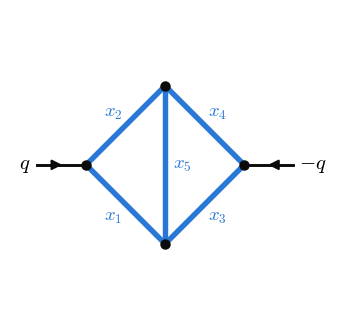

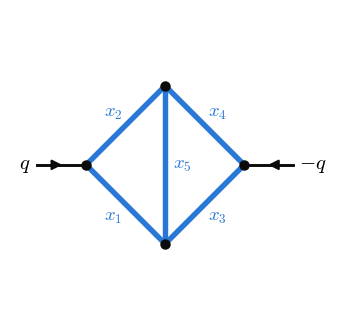

In [202]:
reset(); forget()                  # each box of the note starts from a clean slate
from feynsage import *
g = graph("L-B, L-T, B-R, T-R, T-B", {"L": "q", "R": "-q"}, kin={"q^2": 1}, euclidean=True)
g.plot(figsize=(2.6, 2.6))

The graph method: spanning trees give U, spanning 2-forests give F (and Kirchhoff's matrix-tree theorem agrees)

In [203]:
len(g.spanning_trees()), len(g.two_forests()), g.U(), g.F(), g.U() == g.U_kirchhoff()

(8,
 10,
 x1*x3 + x2*x3 + x1*x4 + x2*x4 + x1*x5 + x2*x5 + x3*x5 + x4*x5,
 x1*x2*x3 + x1*x2*x4 + x1*x3*x4 + x2*x3*x4 + x1*x2*x5 + x2*x3*x5 + x1*x4*x5 + x3*x4*x5,
 True)

The eight spanning trees, drawn (dashed lines are the ones removed)

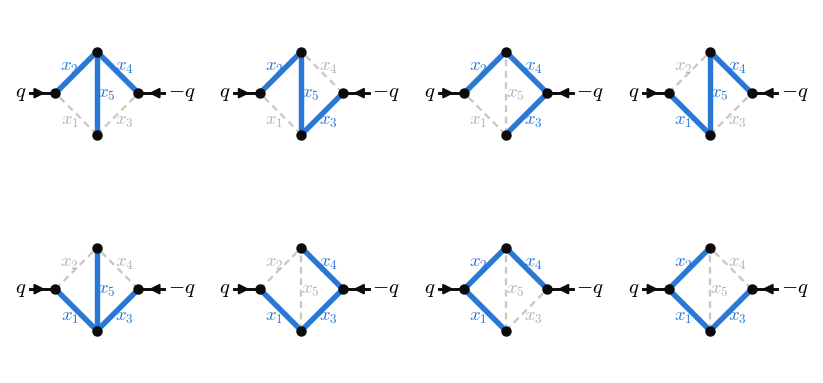

In [204]:
from feynsage.plotting import draw_panels
draw_panels(g, g.spanning_trees(), ncols=4, size=1.4)

The integral family read off the same graph, and IBP down to master integrals.

In [205]:
props, loops = g.family()
K = IntegralFamily("K", loops, g.kin, props)
r = ibp_reduce(K, [(1, 1, 1, 1, 1)])
r

K(1,1,1,1,1) = [(-2) * (d - 4)^-1 * (d - 3)] K(1,1,1,1,0) + [(18) * (d - 4)^-2 * (d - 10/3) * (d - 8/3)] K(0,1,1,0,1)

The reduction drawn as an equation of diagrams.

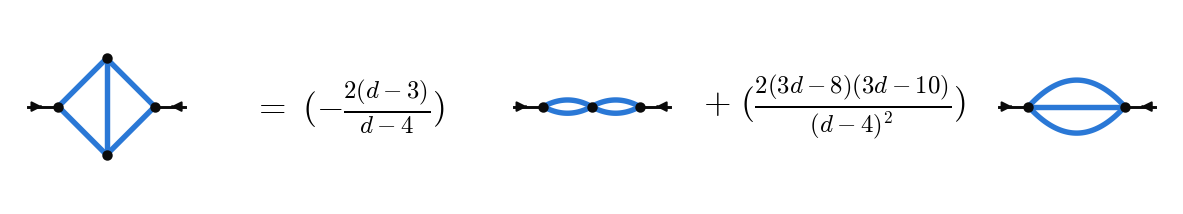

In [206]:
r.draw(g, size=1.6, fontsize=17)

The masters are bubbles: put in their Gamma functions and expand at d = 4 - 2 eps: 6 zeta(3)

In [207]:
d = var('d')
G = lambda a, b: gamma(a + b - d/2)*gamma(d/2 - a)*gamma(d/2 - b)/(gamma(a)*gamma(b)*gamma(d - a - b))
value = {(1, 1, 1, 1, 0): G(1, 1)^2, (0, 1, 1, 0, 1): G(1, 1)*G(1, 2 - d/2)}      # two bubbles; a bubble in a bubble
laurent(sum(SR(str(c))*value[m] for m, c in r[(1, 1, 1, 1, 1)].items()).subs(d=4 - 2*eps), eps, 0)

6*zeta(3)

The one-loop massless triangle three ways. 1: the one-loop library (closed form, Minkowski, s = -1, mu = 1)

In [208]:
s = var('s')
tri = loop("1", ["l", 0], ["l + p1", 0], ["l + p1 + p2", 0], kin={"p1^2": 0, "p2^2": 0, "p1.p2": "s/2"})
way1 = tri["1"].subs(s=-1, mu=1).substitute_function(LogM, log)
way1

1/12*pi^2 - 1/eps^2

2: from its graph, Feynman parameters, sector decomposition and numerical integration.

In [209]:
gt = graph("A-B, B-C, C-A", {"A": "p1 + p2", "B": "-p1", "C": "-p2"}, kin={"p1^2": 0, "p2^2": 0, "p1.p2": "s/2"})
U, F = SR(gt.U()), SR(gt.F())
xs = [SR.var('x%d' % i) for i in (1, 2, 3)]
secs = sector_decompose([(U, -1 + 2*eps), (F, -1 - eps)], xs)
way2 = (laurent(-gamma(1 + eps)*exp(eps*euler_gamma), eps, 2)*integrate_sectors(secs, eps, 0, {s: -1})).expand()
[round(way2.coefficient(eps, k), 12) + 0 for k in (-2, -1, 0)]        # numbers, rounded to 12 digits

[-1.0, 0.0, 0.822467033424]

3: the Gamma-function formula; way 1 minus way 3, and way 2 against way 3 to 12 digits.

In [210]:
way3 = laurent(-exp(eps*euler_gamma)*gamma(1 + eps)*gamma(-eps)^2/gamma(1 - 2*eps), eps, 0)
(way1 - way3).simplify_full(), [bool(abs((way2.coefficient(eps, k) - way3.coefficient(eps, k)).n()) < 1e-12) for k in (-2, -1, 0)]

(0, [True, True, True])

## Where to go next

- `04_feynsage_toolbox.ipynb`: the tools of the last sections in more detail (graphs, families, reduction with
  finite fields, master integrals, differential equations, plotting, parallel work).
- `docs/REFERENCE.md`: every function of feynsage with its arguments.